# Analysis Notebook for the 02-03-2026 Data set pointed at High AM Run 2

In [1]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, RectangularAperture
# Read in the data from the fits file 
from test_analysis import read_in_fits
from analysis_functions import *

In [3]:
TRIM_FRAMES = (199, -1)

In [4]:
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_3')

Processing 1500 FITS files from ./data/260203/zenith_sky_3
Loaded 1500 FITS files from ./data/260203/zenith_sky_3


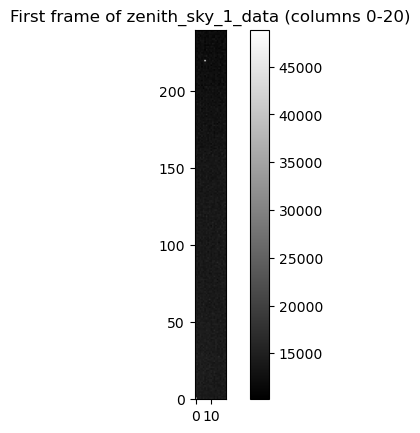

In [5]:
# Pick the first image and just preview columns 0 - 20 and all rows to see what a channel looks like
plt.imshow(zenith_sky_1_data[0, :, :20], cmap='gray', origin='lower')
plt.title("First frame of zenith_sky_1_data (columns 0-20)")
plt.colorbar()
plt.show()

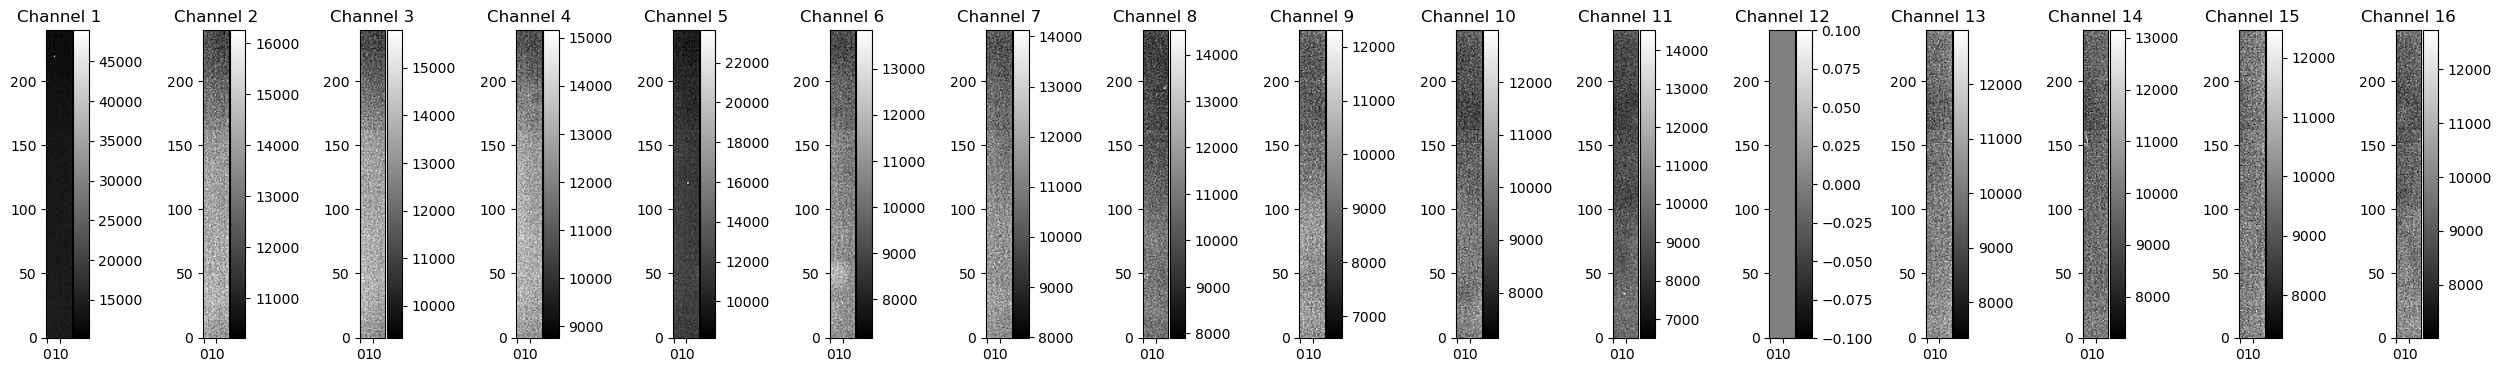

In [6]:
num_channels = 16
channel_data = []

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    channel_data.append(zenith_sky_1_data[:, :, i*20:(i+1)*20])
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {}".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)

plt.show()

## Compute $R(f_c)$

## First define an aperture andf compute the measured variance $\sigma^2(f_c)$ within it

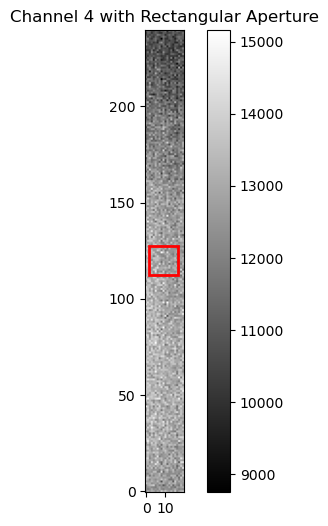

In [7]:
# Take the 4th channel and define a rectangular aperture of radius of size 8 x 8 pixels centered on the middle of the image (no annulus for background subtraction)
channel_4_data = channel_data[3]
aperture = RectangularAperture((9,120), 15, 15) 
# display aperture 
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(channel_4_data[0], cmap='gray', origin='lower')
aperture.plot(color='red', lw=2, ax=ax)
ax.set_title("Channel 4 with Rectangular Aperture")
plt.colorbar(im, ax=ax)
plt.show()  


The 

In [8]:
np.shape(zenith_sky_1_data)

(1500, 240, 320)

In [9]:
# Build channels as bef|ore
result = extract_channels(zenith_sky_1_data, channel_width=20, trim=TRIM_FRAMES)

In [10]:
np.shape(result["channels"])

(16, 1300, 240, 20)

In [11]:
coadds = np.arange(5,300)

In [12]:
# Aperture in channel-local coordinates (x in [0, 19], y in [0, ny-1])
ap = RectangularAperture((9, 120), 15, 15)

variances, t_dwell, f_state, f_coadd, = create_variance_curve(result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap)


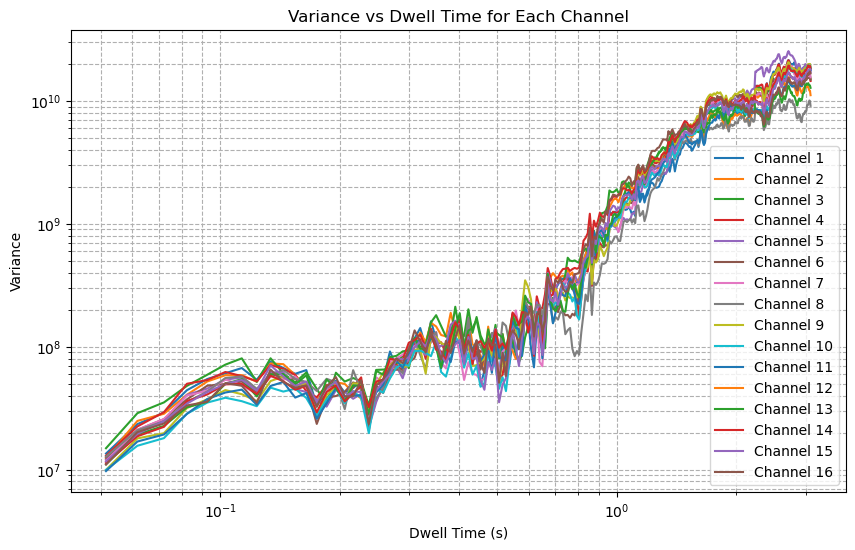

In [13]:
# Plot by dwell time instead 
plt.figure(figsize=(10, 6))
for channel in range(result["channels"].shape[0]):
    channel_variance = [variances[i][channel] for i in range(len(coadds))]
    plt.plot(t_dwell, channel_variance, label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Dwell Time (s)')
plt.ylabel('Variance')
plt.title('Variance vs Dwell Time for Each Channel')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

/tmp/ipykernel_303382/3716431333.py:12: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


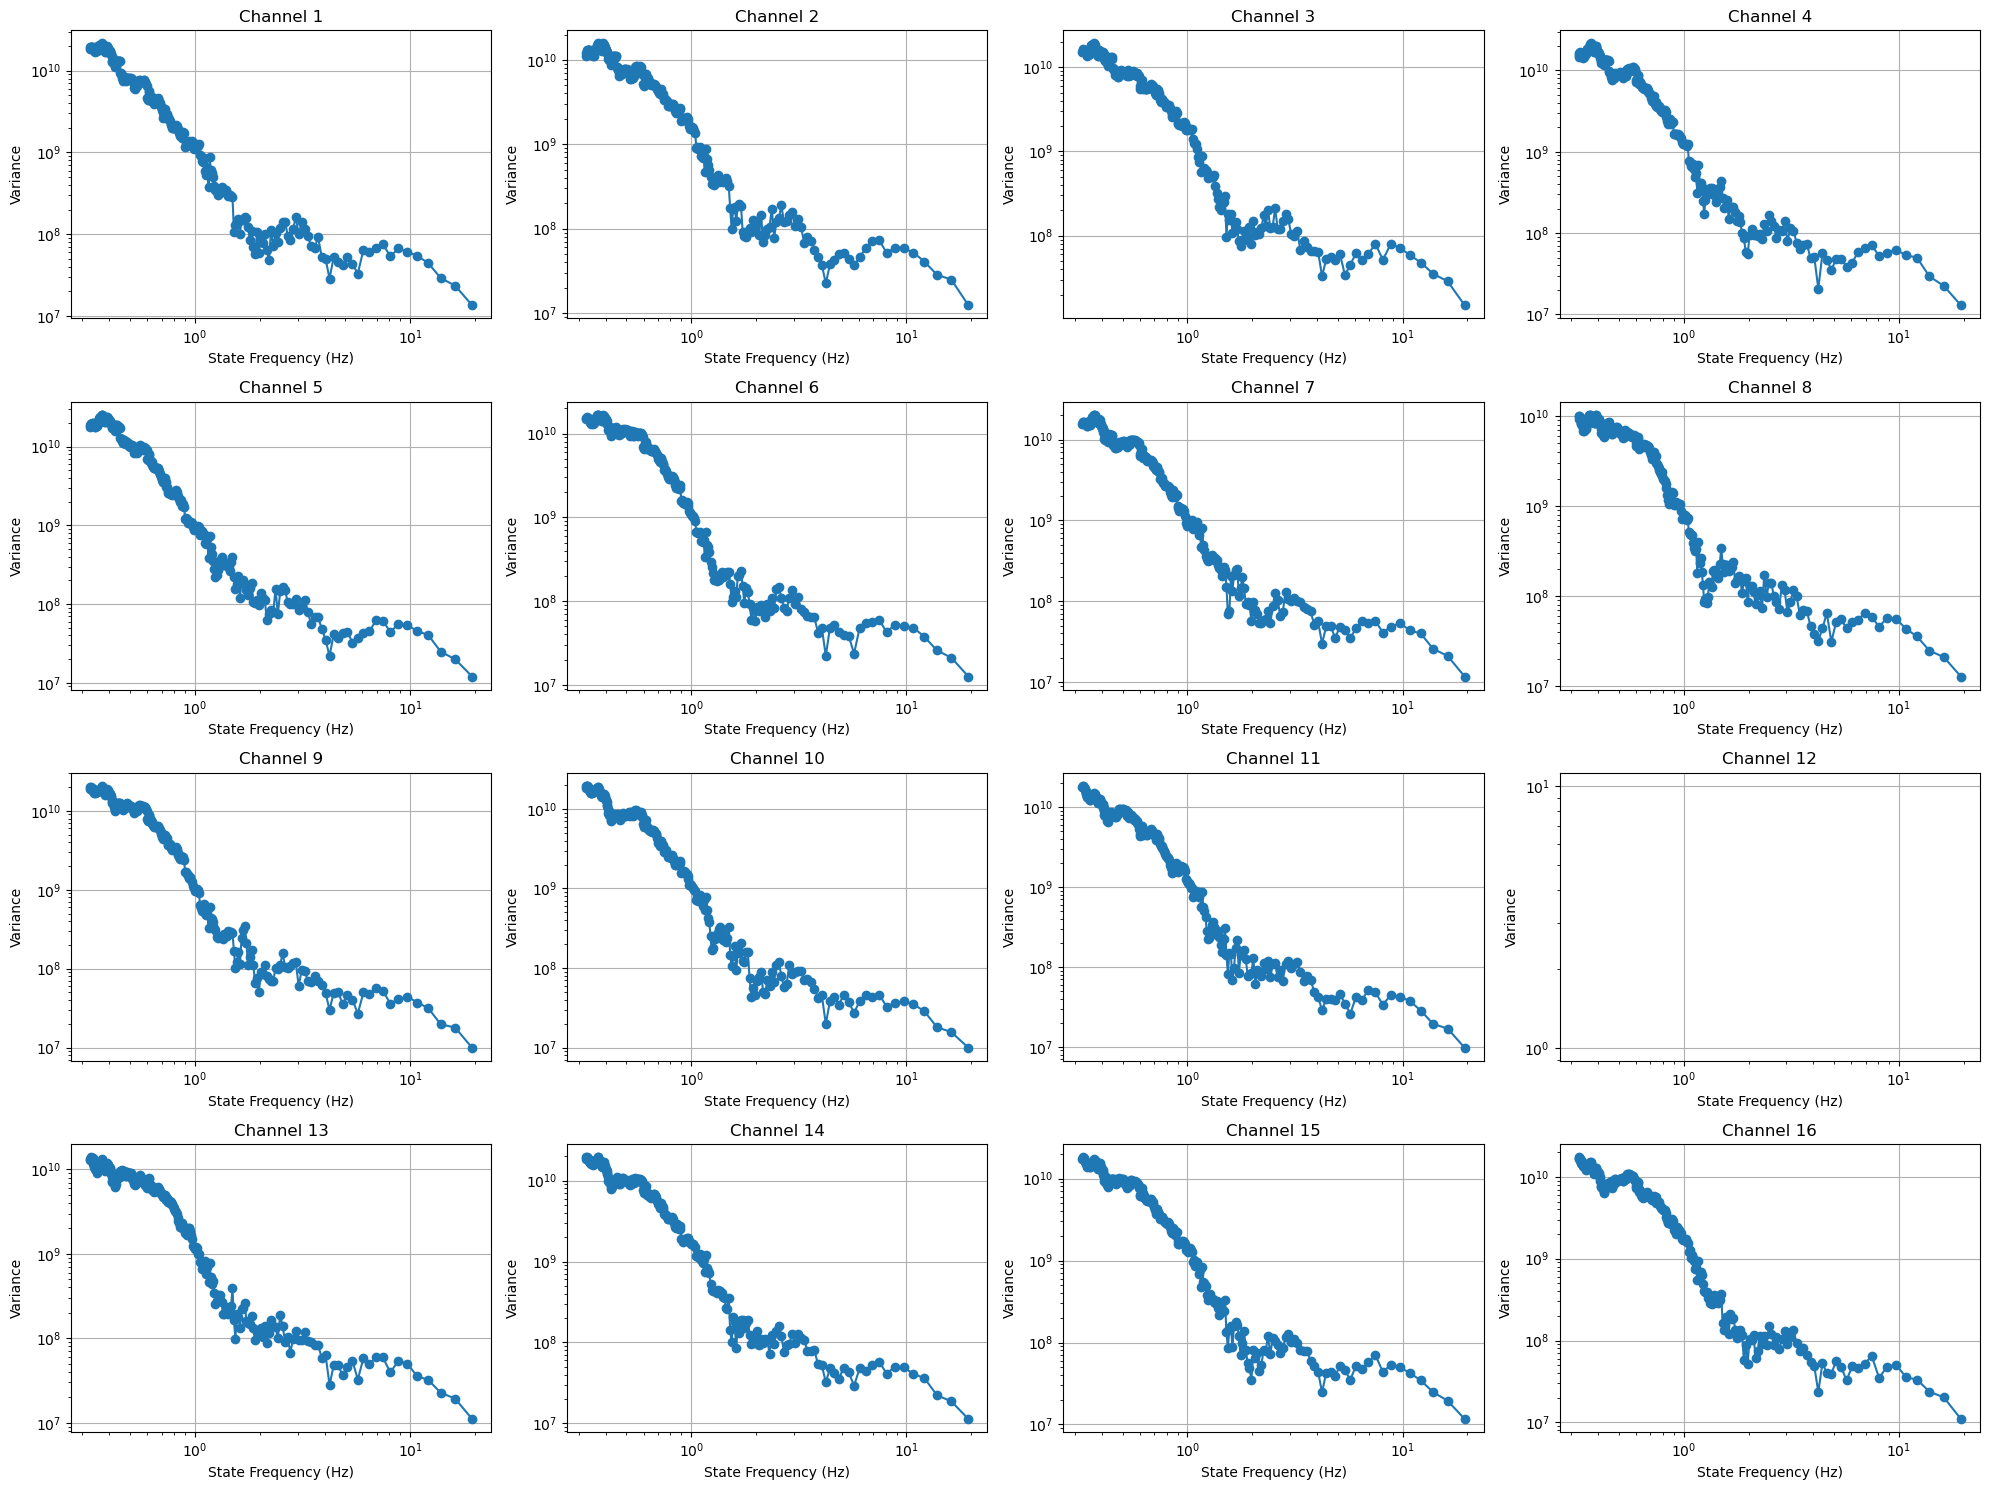

In [14]:
# Loop over all channels and plot the variance curves
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    ch_variance = [variances[i][channel] for i in range(len(coadds))]    
    ax.plot(f_state, ch_variance, marker='o')
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.grid( True )
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.tight_layout()
plt.show()


Great, now set the curve for the fiducial frequency term (say 0.5 Hz)

In [15]:
# Cell: variance at f_OS
f_OS = 0.5  # Hz
sky_variances_at_f_OS = []

for channel in range(result["channels"].shape[0]):
    ch_variance = [variances[i][channel] for i in range(len(coadds))]

    # Keep x-y pairing consistent: both reversed
    variance_at_f_OS = np.interp(f_OS, np.array(f_state)[::-1], ch_variance[::-1])
    sky_variances_at_f_OS.append(variance_at_f_OS)

sky_variances_at_f_OS = np.array(sky_variances_at_f_OS, dtype=float)

/tmp/ipykernel_303382/746053148.py:14: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


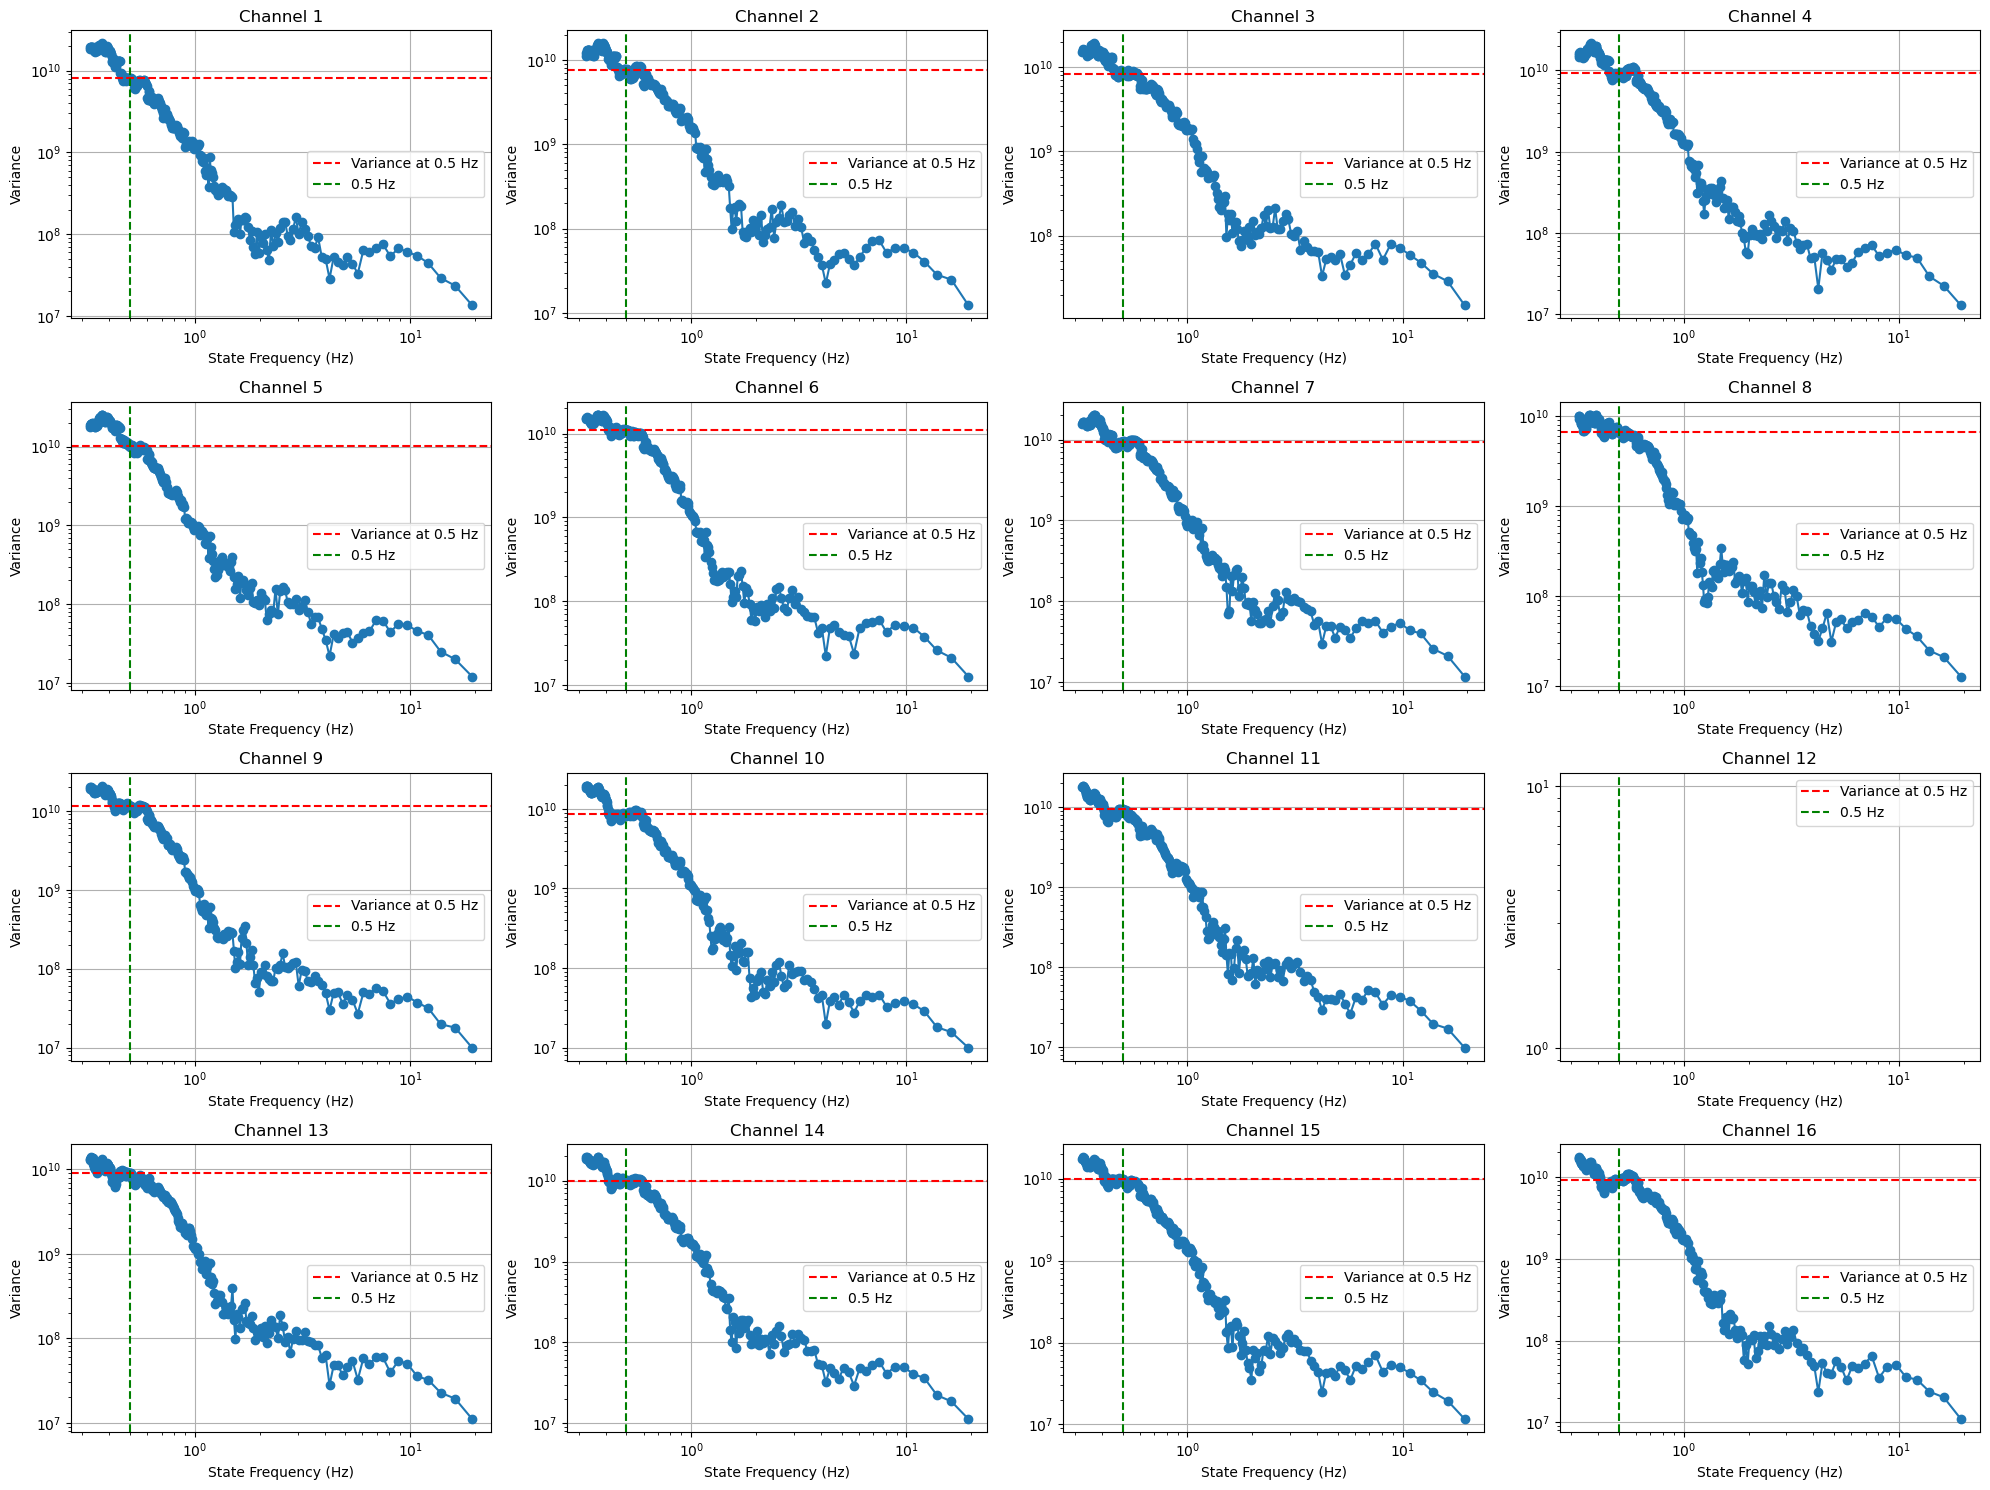

In [16]:
# For each channel, plot the variace curve and mark the variance at f_OS
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    ch_variance = [variances[i][channel] for i in range(len(coadds))]
    ax.plot(f_state, ch_variance, marker='o')
    ax.axhline(sky_variances_at_f_OS[channel], color='red', linestyle='--', label=f'Variance at {f_OS} Hz')
    ax.axvline(f_OS, color='green', linestyle='--', label=f'{f_OS} Hz')
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.grid( True )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# at each channel, divide the variance by the variance at f_OS to get a normalized variance curve
# Initialize array with with shape (num_channels, state_frequencies)
# Cell: R_factor
ch_var_matrix = np.array([[variances[n][ch] for n in range(len(coadds))]
                          for ch in range(result["channels"].shape[0])], dtype=float)

# Safe divide; invalid denominators become NaN
den = sky_variances_at_f_OS[:, None]
R_factor = np.divide(
    ch_var_matrix, den,
    out=np.full_like(ch_var_matrix, np.nan),
    where=np.isfinite(den) & (den > 0)
)

In [18]:
np.shape(R_factor)

(16, 295)

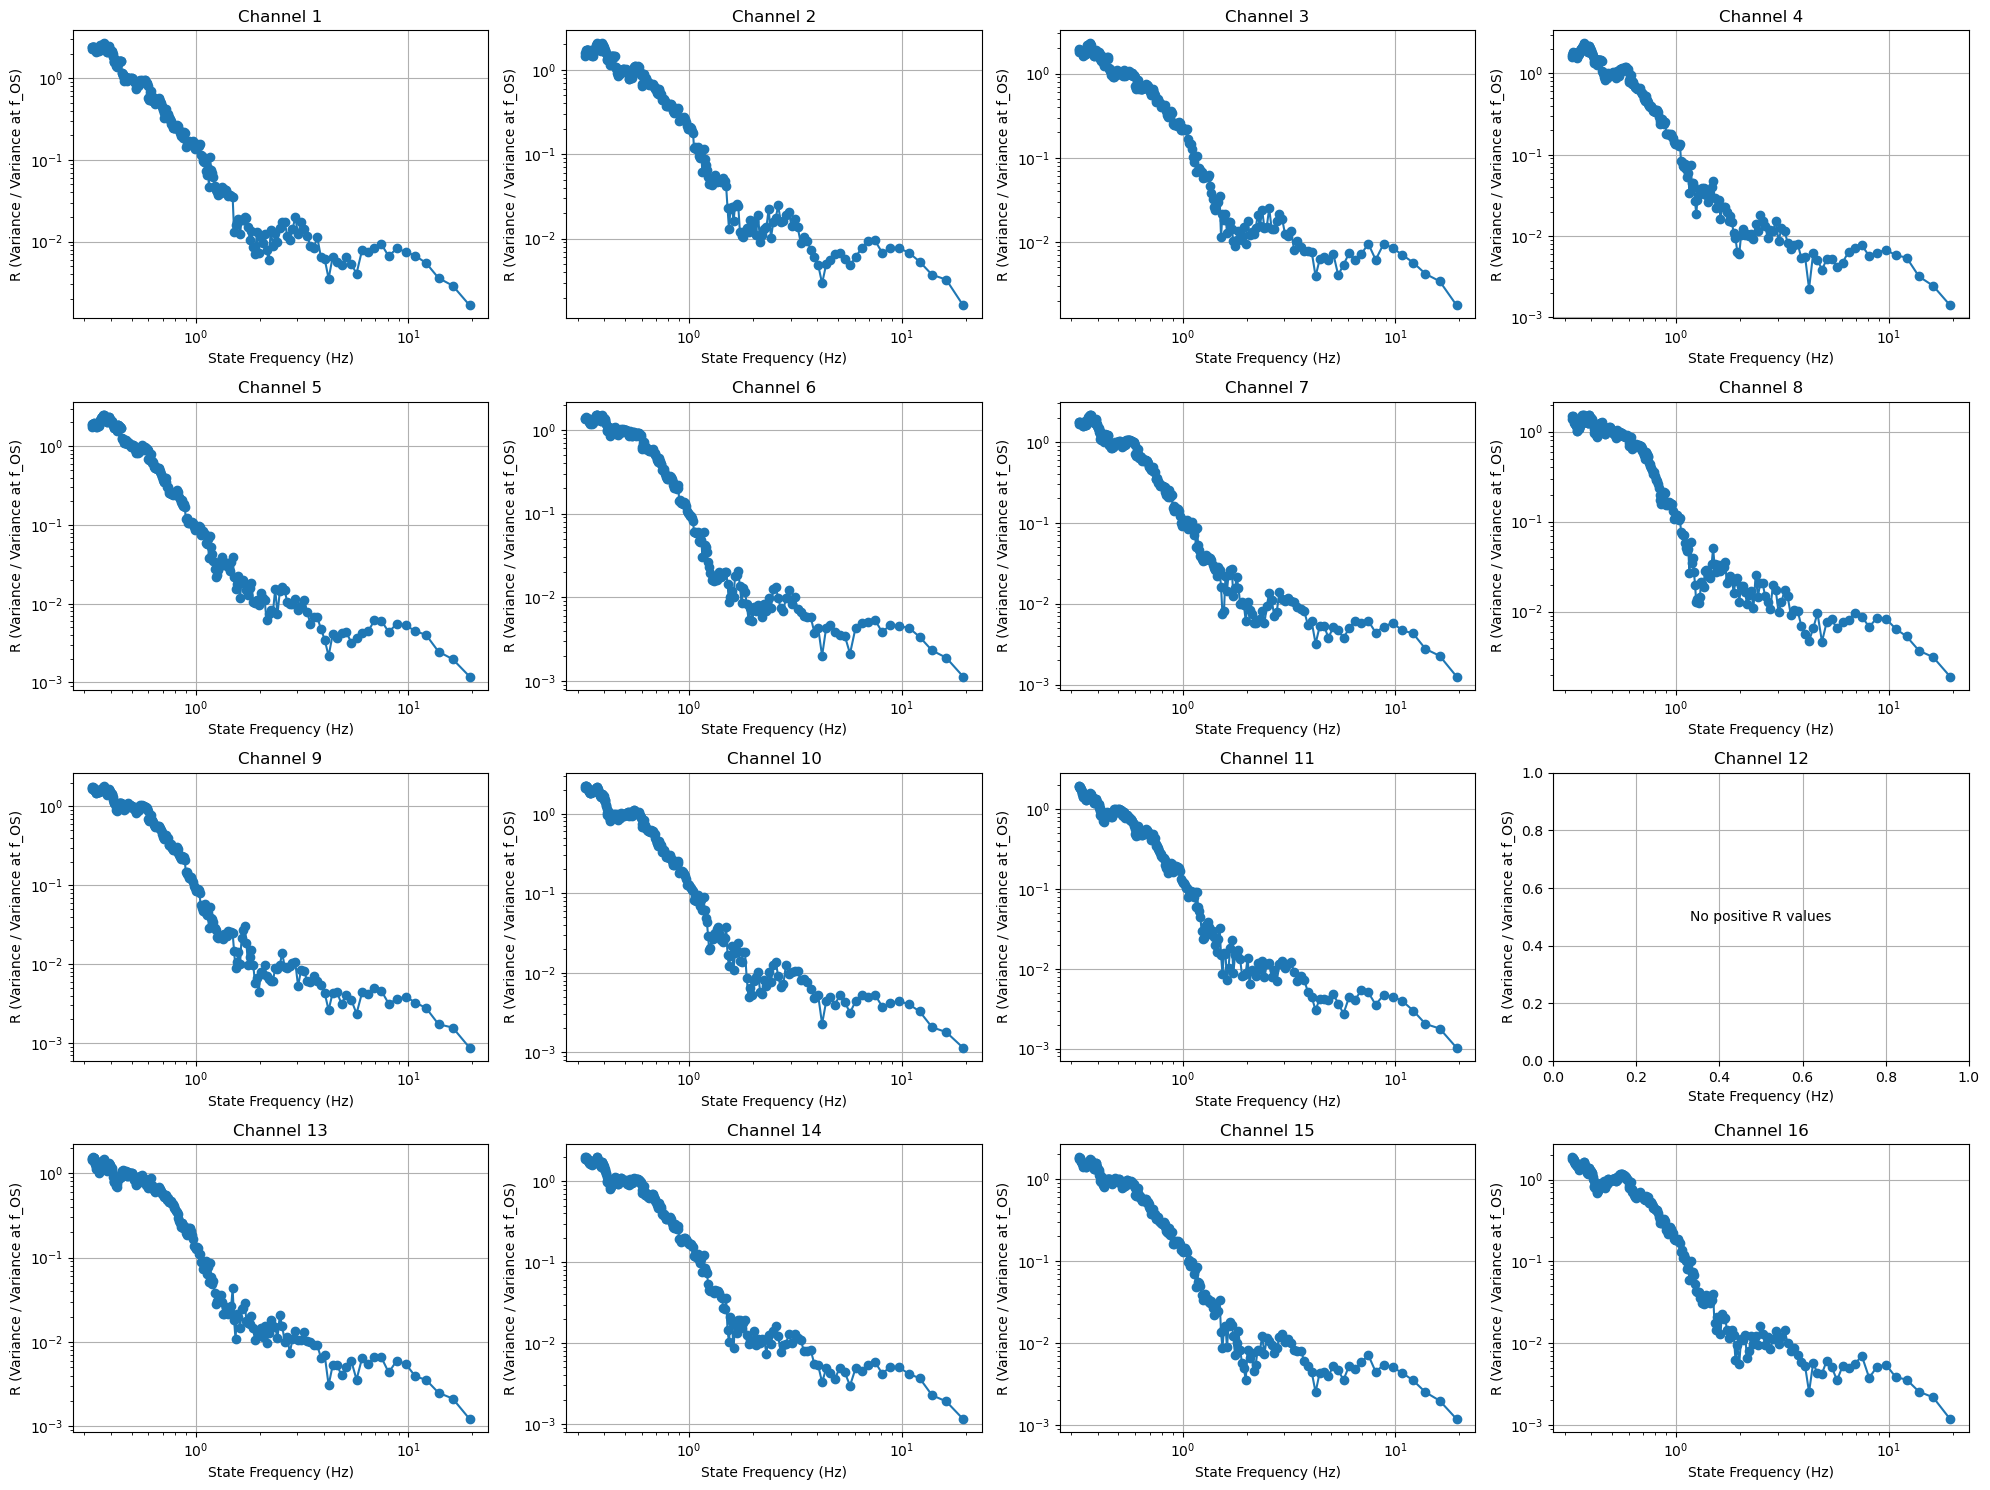

In [19]:
# Cell: Plot R
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = np.isfinite(R_values) & (R_values > 0) & np.isfinite(xvals) & (xvals > 0)

    if np.any(good):
        ax.plot(xvals[good], R_values[good], marker='o')
        ax.set_xscale('log')
        ax.set_yscale('log')
    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at f_OS)')
    ax.grid(True)


plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


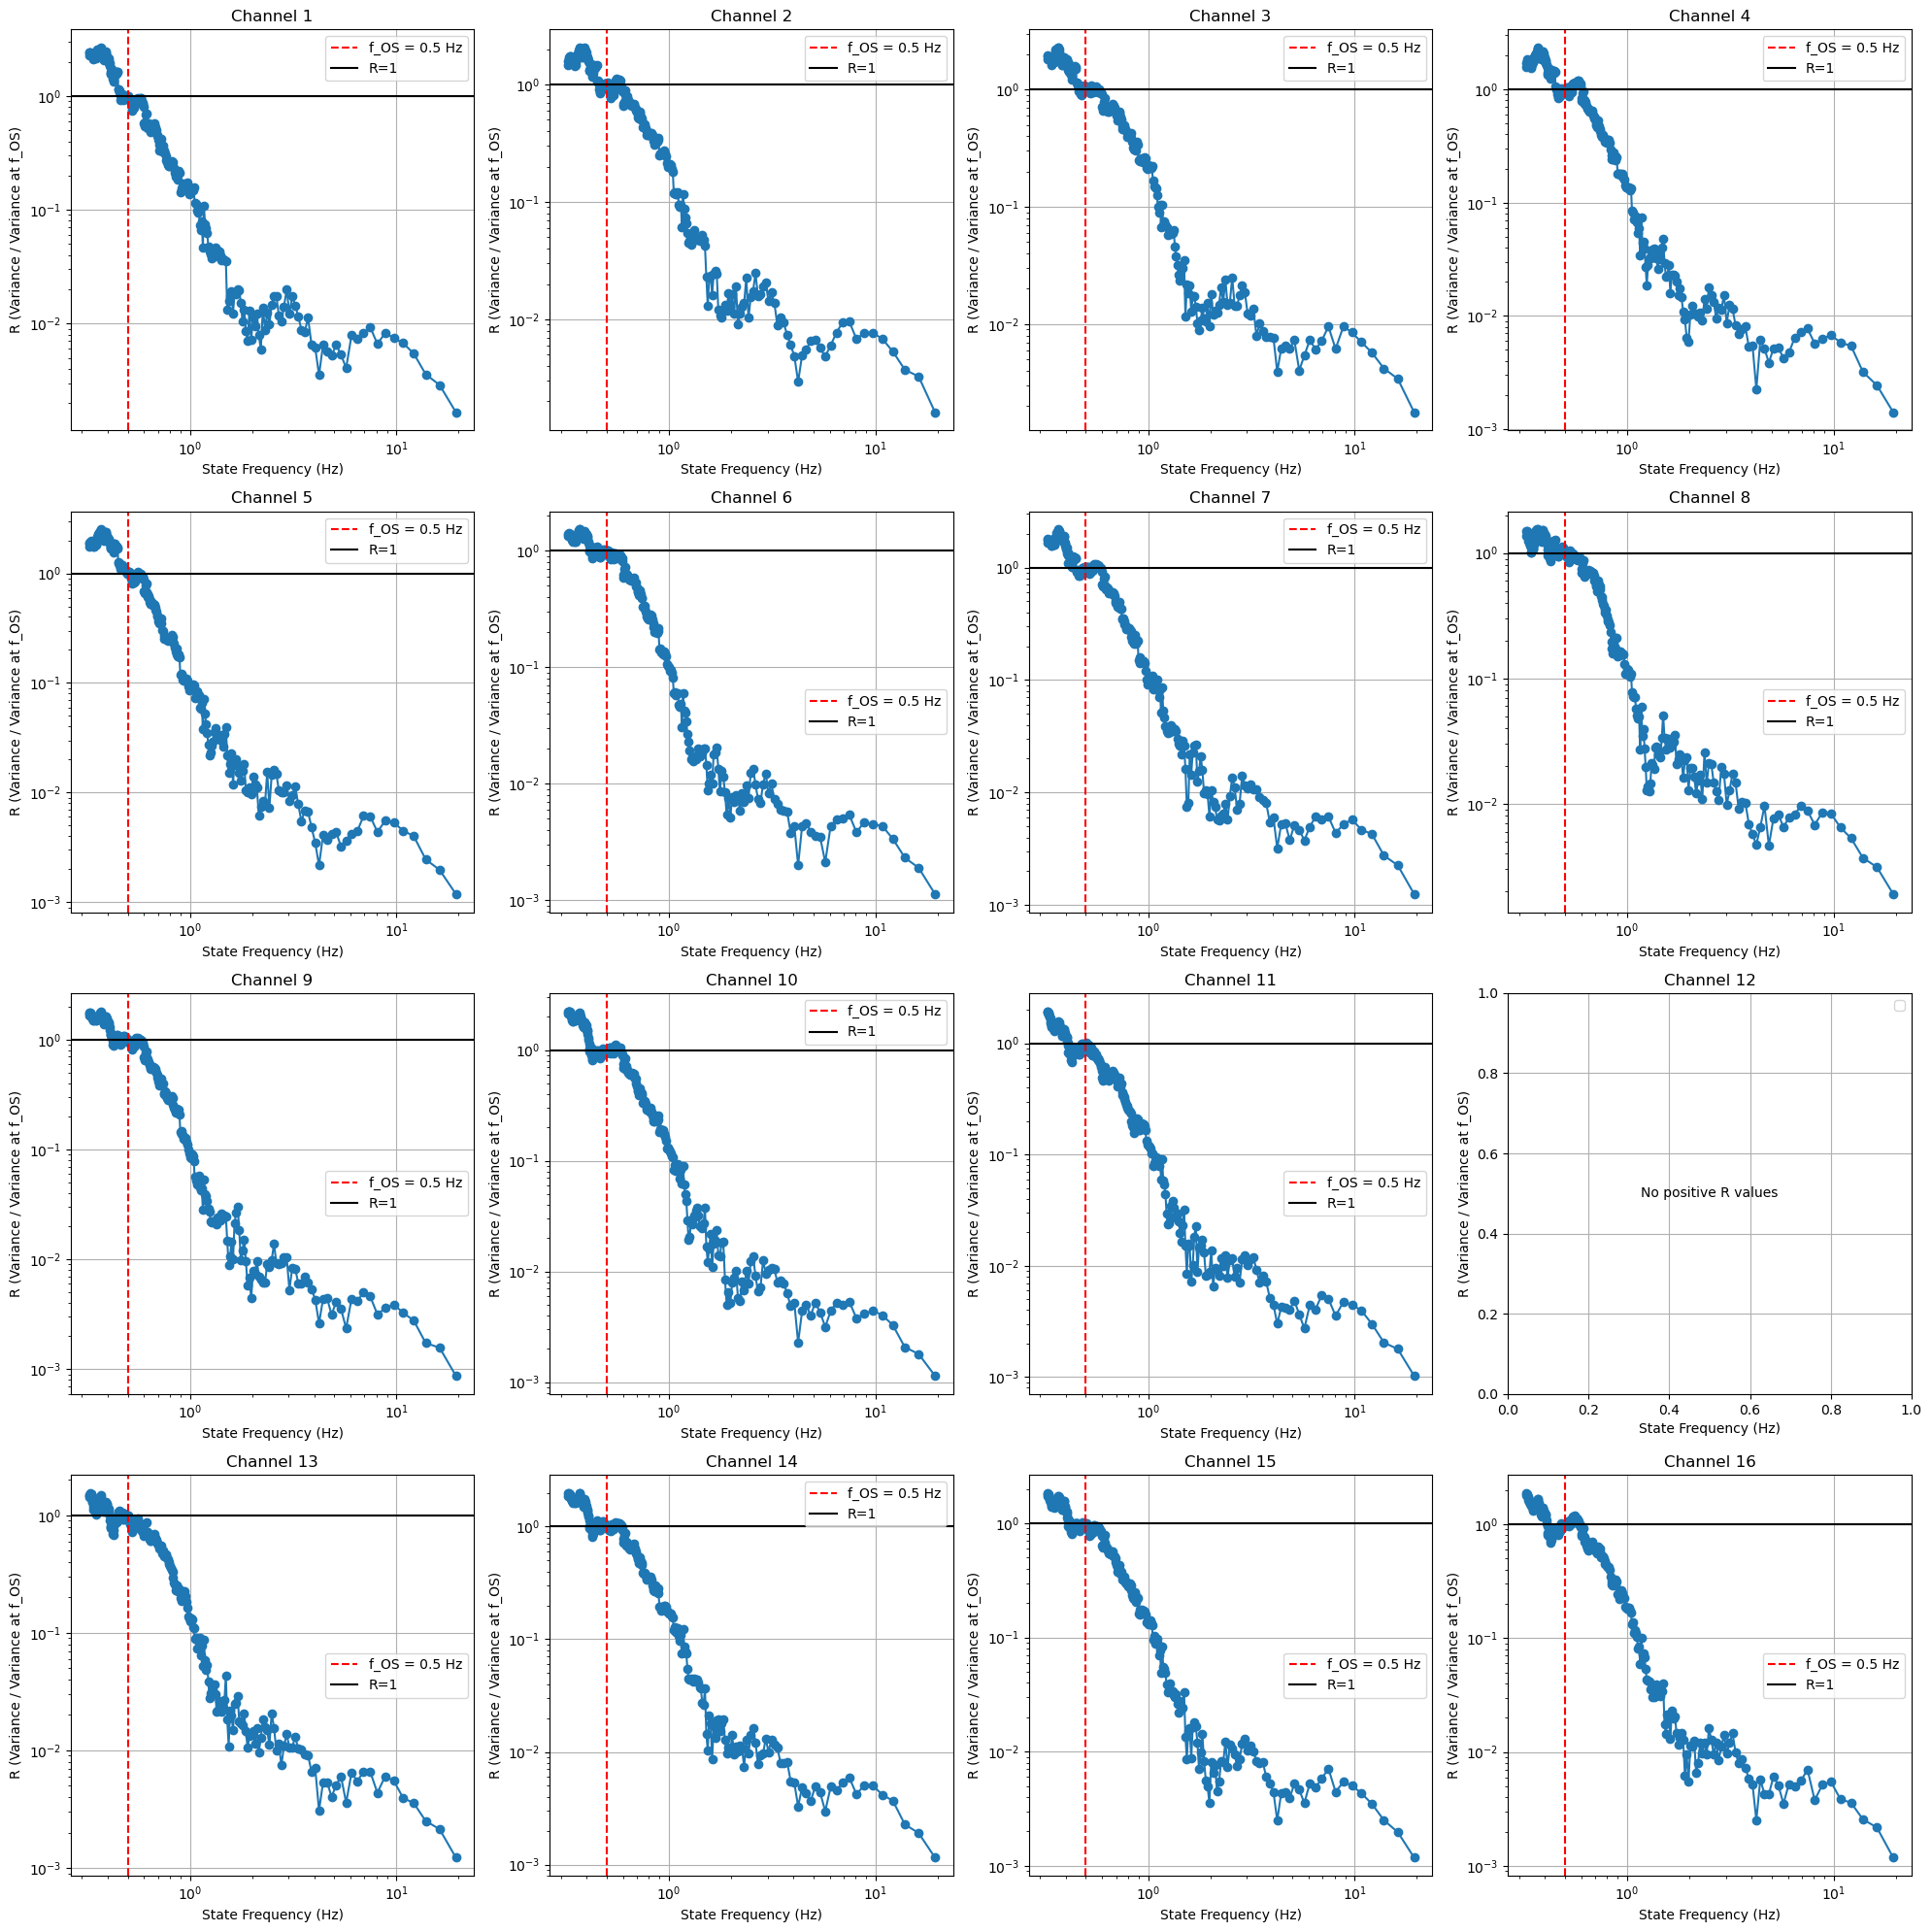

In [20]:
# Great, let's repeat the plot but using marking the F_OS point with a vertical dashed line, a black horizontal line ar R = 1, and a red fill (for the entire region) for R > 1 and a light green fill for R < 1 with text that says "no chopping improvment" 
fig, axes = plt.subplots(4, 4, figsize=(20,20))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = np.isfinite(R_values) & (R_values > 0) & np.isfinite(xvals) & (xvals > 0)

    if np.any(good):
        ax.plot(xvals[good], R_values[good], marker='o')
        ax.set_xscale('log')
        ax.set_yscale('log')

        # Add vertical line at f_OS
        ax.axvline(f_OS, color='red', linestyle='--', label=f'f_OS = {f_OS} Hz')

        # Add horizontal line at R=1
        ax.axhline(1, color='black', linestyle='-', label='R=1')

    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at f_OS)')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()


So, anything to the right of this line indicates an improvement from chopping. 

We use the sky_emission python file to compute a fudicial rate for the sky given. 

In [21]:
sky_rate = 2.425e9 #ph/s/m^2/arcsec^2
tel_rate = 1.511e9 #ph/s/m^2/arcsec^2

In [22]:
# Efficiency values
E_primary_mirror = 0.95
E_secondary_mirror = 0.98
E_dichroic = 0.94
E_ZnSe = 0.95
E_M1 = 0.95
E_M2 = 0.96 
E_Nband = 0.5 
E_BaF2 = 0.7 
E_cold_stop = 0.9
E_M3 = 0.96 
E_M4 = 0.96 
QE = 0.4

In [23]:
eta_tel = (E_secondary_mirror * E_dichroic * E_ZnSe * E_M1 * E_M2 * E_BaF2 * E_cold_stop * E_M3 * E_M4) # total telescope efficiency

In [24]:
print(f"Total telescope efficiency (eta_tel): {eta_tel:.3f}")

Total telescope efficiency (eta_tel): 0.463


In [25]:
# Total sky photons 
sky_rate_after_efficiency = sky_rate * E_primary_mirror * eta_tel * QE

In [26]:
print(f"Sky rate after efficiency (sky_rate_after_efficiency): {sky_rate_after_efficiency:.3e} ph/s/m^2/arcsec^2")

Sky rate after efficiency (sky_rate_after_efficiency): 4.270e+08 ph/s/m^2/arcsec^2


In [27]:
# Solid angle of MIRSI pixel
pixel_scale_arcsec = 0.27 # arcsec/pixel
omega_pix = pixel_scale_arcsec ** 2  # arcsec^2/pixel

# Collecting area of IRTF
D = 3.2 # Meters 
A_tel = np.pi * (D / 2) ** 2  # m^2

# Total sky photons per pixel per second
sky_photons_per_pixel_per_second = sky_rate_after_efficiency * A_tel * omega_pix

print(f"Sky photons per second per pixel: {sky_photons_per_pixel_per_second:.3e} ph/s") 

Sky photons per second per pixel: 2.504e+08 ph/s


## Calcuation of $\sigma^2_{corr,ref}$

First, we compute the fractional change in the sky frames (within the aperture) at the characteristic O-S frequency. 

In [28]:
# Bin the data so that the state frequency is f_OS = 0.5 Hz, which means we need to bin every 1/f_OS = 2 seconds. With a frame time of 0.0103 seconds, that means we need to bin every 2 / 0.0103 ≈ 194 frames.
bin_size = int(2 / 0.0103)  # Number of frames to bin together to achieve f_OS = 0.5 Hz
binned_channels = []
for channel in range(result["channels"].shape[0]):
    ch_data = result["channels"][channel]
    num_bins = ch_data.shape[0] // bin_size
    binned_ch = ch_data[:num_bins * bin_size].reshape(num_bins, bin_size, *ch_data.shape[1:]).mean(axis=1)
    binned_channels.append(binned_ch)
binned_channels = np.array(binned_channels)

In [29]:
np.shape(binned_channels)

(16, 6, 240, 20)

In [30]:
# for each binned channel find the average value of the pixel in the aperature and find the fractional variation of the pixel values in the aperture across all frames for that channel. Plot this fractional variation as a function of channel number to see if it correlates with the variance curves.
bad_channels = [11]
# Initialize array to store all the fractional variations for each channel
channel_var_del = np.zeros(binned_channels.shape[0])
for channel in range(binned_channels.shape[0]):
    if channel in bad_channels:
        print(f"Skipping Channel {channel+1} due to known issues.")
        continue
    # Initialize array for the stack variances for this channel should have shape (num_frames,)
    stack_variances = np.zeros(binned_channels.shape[1])
    # Loop over all frames in the channel compute the mean in the aperture and find the fractional change for every pixel 
    for i in range(binned_channels.shape[1]):
        # Create aperture
        ap = RectangularAperture((9, 120), 17, 17)
        mask = ap.to_mask(method='center')

        # Extract just the region inside the aperture
        # mask.bbox gives you the bounding box of the aperture
        cropped_frame = mask.multiply(binned_channels[channel, i])
        mean_ap = np.mean(cropped_frame[cropped_frame > 0]) # only take the mean of the pixels that are inside the aperture (non-zero values)
      
        # Now compute the fractional change for every pixel in the aperture and then compute the variance of the fractional change across all pixels in the aperture for this frame
        frac_change = (cropped_frame[cropped_frame > 0] - mean_ap) / mean_ap
        
        # Compute the variance of the fractional change across all pixels in the aperture for this frame and store it in the stack_variances array
        stack_variances[i] = np.var(frac_change)

    # Now we have the variance of the fractional change for each frame in this channel, we can compute the mean variance across all frames for this channel and store it in the channel_var_del array
    channel_var_del[channel] = np.mean(stack_variances)


Skipping Channel 12 due to known issues.


In [31]:
print("Fractional variation of pixel values in the aperture for each channel:")
for channel in range(result['channels'].shape[0]):
    if channel not in bad_channels:
        print(f"Channel {channel+1}: {channel_var_del[channel]}")

Fractional variation of pixel values in the aperture for each channel:
Channel 1: 0.00575368102819155
Channel 2: 0.004420152451474461
Channel 3: 0.005804432114797422
Channel 4: 0.006542351744789719
Channel 5: 0.0214971438994085
Channel 6: 0.011071461649328831
Channel 7: 0.006410155343060694
Channel 8: 0.007448049596871858
Channel 9: 0.012481890583969495
Channel 10: 0.010820287731750334
Channel 11: 0.013071687162702614
Channel 13: 0.01002779804685589
Channel 14: 0.01249669719459315
Channel 15: 0.01390294673689176
Channel 16: 0.012610347026334423


Since we know the sky rate in electrons per 

var_corr_ref = ()

In [32]:
var_corr_ref =((sky_photons_per_pixel_per_second / f_OS)**2) * channel_var_del

In [33]:
print("correlated reference variance for each channel:")
print(var_corr_ref)

correlated reference variance for each channel:
[1.44258683e+15 1.10823900e+15 1.45531135e+15 1.64032563e+15
 5.38985328e+15 2.77588289e+15 1.60718080e+15 1.86740596e+15
 3.12951150e+15 2.71290752e+15 3.27738775e+15 0.00000000e+00
 2.51421121e+15 3.13322387e+15 3.48580460e+15 3.16171863e+15]


## Compute Number of Effective Samples

As a check, find the autocorrelation timescale of the aperture sum in the images from "result"

In [34]:
# for each channel, Sum the counts in the aperture for the timeseries for each channel and compute the autocorrelation. 

# Step 1: build time series
timeseries_by_coadd, meta = build_timeseries_by_coadd(
result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap
)

# Step 2: analyze correlations
acf_by_coadd, tau_by_coadd, neff_by_coadd = analyze_autocorrelation(
    timeseries_by_coadd
)

In [35]:
import numpy as np
import matplotlib.pyplot as plt


def plot_acf_by_coadd(acf_by_coadd, f_state_by_coadd, channel=0):
    """
    Plot autocorrelation vs lag for one chosen channel, for all coadds.

    Parameters
    ----------
    acf_by_coadd : dict
        {n: ndarray of shape (N_lags, n_channels) or None}
    f_state_by_coadd : dict
        {n: f_state}
    channel : int
        Channel index to plot.
    """
    plt.figure(figsize=(8, 5))

    for n in sorted(acf_by_coadd.keys()):
        acf = acf_by_coadd[n]
        if acf is None:
            continue
        if channel >= acf.shape[1]:
            continue

        lags = np.arange(acf.shape[0])
        plt.plot(
            lags,
            acf[:, channel],
            marker='o',
            label=f"n={n}, f_state={f_state_by_coadd[n]:.2f} Hz"
        )

    plt.axhline(0, color='k', linewidth=1)
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.title(f"Autocorrelation by coadd (channel {channel})")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    

In [36]:
def plot_abs_acf_by_coadd(acf_by_coadd, f_state_by_coadd, channel=0):
    """
    Plot |autocorrelation| vs lag for one chosen channel, for all coadds.
    """
    plt.figure(figsize=(8, 5))

    for n in sorted(acf_by_coadd.keys()):
        acf = acf_by_coadd[n]
        if acf is None:
            continue
        if channel >= acf.shape[1]:
            continue

        lags = np.arange(acf.shape[0])
        plt.plot(
            lags,
            np.abs(acf[:, channel]),
            marker='o',
            label=f"n={n}, f_state={f_state_by_coadd[n]:.2f} Hz"
        )

    plt.xlabel("Lag")
    plt.ylabel("|ACF|")
    plt.title(f"Absolute autocorrelation by coadd (channel {channel})")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [37]:
def plot_tau_by_coadd_vs_fstate(tau_by_coadd, f_state_by_coadd, show_errorbars=True):
    """
    Plot mean tau_int across channels vs f_state.

    Parameters
    ----------
    tau_by_coadd : dict
        {n: ndarray of tau_int values per channel}
    f_state_by_coadd : dict
        {n: f_state}
    show_errorbars : bool
        If True, plot std dev across channels as error bars.
    """
    coadds = sorted(tau_by_coadd.keys())

    f_state_vals = []
    tau_means = []
    tau_stds = []

    for n in coadds:
        tau = np.asarray(tau_by_coadd[n], dtype=float)
        mask = np.isfinite(tau)

        if not np.any(mask):
            continue

        f_state_vals.append(f_state_by_coadd[n])
        tau_means.append(np.nanmean(tau[mask]))
        tau_stds.append(np.nanstd(tau[mask]))

    f_state_vals = np.array(f_state_vals)
    tau_means = np.array(tau_means)
    tau_stds = np.array(tau_stds)

    order = np.argsort(f_state_vals)
    f_state_vals = f_state_vals[order]
    tau_means = tau_means[order]
    tau_stds = tau_stds[order]

    plt.figure(figsize=(7, 5))
    if show_errorbars:
        plt.errorbar(f_state_vals, tau_means, yerr=tau_stds, marker='o', capsize=3)
    else:
        plt.plot(f_state_vals, tau_means, marker='o')

    plt.xscale("log")
    plt.xlabel(r"$f_{\mathrm{state}}$ [Hz]")
    plt.ylabel(r"$\tau_{\mathrm{int}}$ [samples]")
    plt.title(r"Integrated autocorrelation time vs $f_{\mathrm{state}}$")
    plt.tight_layout()
    plt.show()

In [38]:
def plot_neff_by_coadd_vs_fstate(neff_by_coadd, f_state_by_coadd, show_errorbars=True):
    """
    Plot mean N_eff across channels vs f_state.
    """
    coadds = sorted(neff_by_coadd.keys())

    f_state_vals = []
    neff_means = []
    neff_stds = []

    for n in coadds:
        neff = np.asarray(neff_by_coadd[n], dtype=float)
        mask = np.isfinite(neff)

        if not np.any(mask):
            continue

        f_state_vals.append(f_state_by_coadd[n])
        neff_means.append(np.nanmean(neff[mask]))
        neff_stds.append(np.nanstd(neff[mask]))

    f_state_vals = np.array(f_state_vals)
    neff_means = np.array(neff_means)
    neff_stds = np.array(neff_stds)

    order = np.argsort(f_state_vals)
    f_state_vals = f_state_vals[order]
    neff_means = neff_means[order]
    neff_stds = neff_stds[order]

    plt.figure(figsize=(7, 5))
    if show_errorbars:
        plt.errorbar(f_state_vals, neff_means, yerr=neff_stds, marker='o', capsize=3)
    else:
        plt.plot(f_state_vals, neff_means, marker='o')

    plt.xscale("log")
    plt.xlabel(r"$f_{\mathrm{state}}$ [Hz]")
    plt.ylabel(r"$N_{\mathrm{eff}}$")
    plt.title(r"Effective sample size vs $f_{\mathrm{state}}$")
    plt.tight_layout()
    plt.show()

In [39]:
def plot_tau_all_channels_vs_fstate(tau_by_coadd, f_state_by_coadd):
    """
    Plot tau_int for every channel vs f_state.
    """
    coadds = sorted(tau_by_coadd.keys())
    all_channels = len(next(iter(tau_by_coadd.values())))

    plt.figure(figsize=(8, 5))

    for ch in range(all_channels):
        fvals = []
        tvals = []

        for n in coadds:
            tau = np.asarray(tau_by_coadd[n], dtype=float)
            if ch >= len(tau):
                continue
            if not np.isfinite(tau[ch]):
                continue

            fvals.append(f_state_by_coadd[n])
            tvals.append(tau[ch])

        if len(fvals) > 0:
            order = np.argsort(fvals)
            fvals = np.array(fvals)[order]
            tvals = np.array(tvals)[order]
            plt.plot(fvals, tvals, marker='o', alpha=0.6)

    plt.xscale("log")
    plt.xlabel(r"$f_{\mathrm{state}}$ [Hz]")
    plt.ylabel(r"$\tau_{\mathrm{int}}$ [samples]")
    plt.title(r"All channels: $\tau_{\mathrm{int}}$ vs $f_{\mathrm{state}}$")
    plt.tight_layout()
    plt.show()

In [40]:
def plot_neff_all_channels_vs_fstate(neff_by_coadd, f_state_by_coadd):
    """
    Plot N_eff for every channel vs f_state.
    """
    coadds = sorted(neff_by_coadd.keys())
    all_channels = len(next(iter(neff_by_coadd.values())))

    plt.figure(figsize=(8, 5))

    for ch in range(all_channels):
        fvals = []
        nvals = []

        for n in coadds:
            neff = np.asarray(neff_by_coadd[n], dtype=float)
            if ch >= len(neff):
                continue
            if not np.isfinite(neff[ch]):
                continue

            fvals.append(f_state_by_coadd[n])
            nvals.append(neff[ch])

        if len(fvals) > 0:
            order = np.argsort(fvals)
            fvals = np.array(fvals)[order]
            nvals = np.array(nvals)[order]
            plt.plot(fvals, nvals, marker='o', alpha=0.6)

    plt.xscale("log")
    plt.xlabel(r"$f_{\mathrm{state}}$ [Hz]")
    plt.ylabel(r"$N_{\mathrm{eff}}$")
    plt.title(r"All channels: $N_{\mathrm{eff}}$ vs $f_{\mathrm{state}}$")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1522175/355709316.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


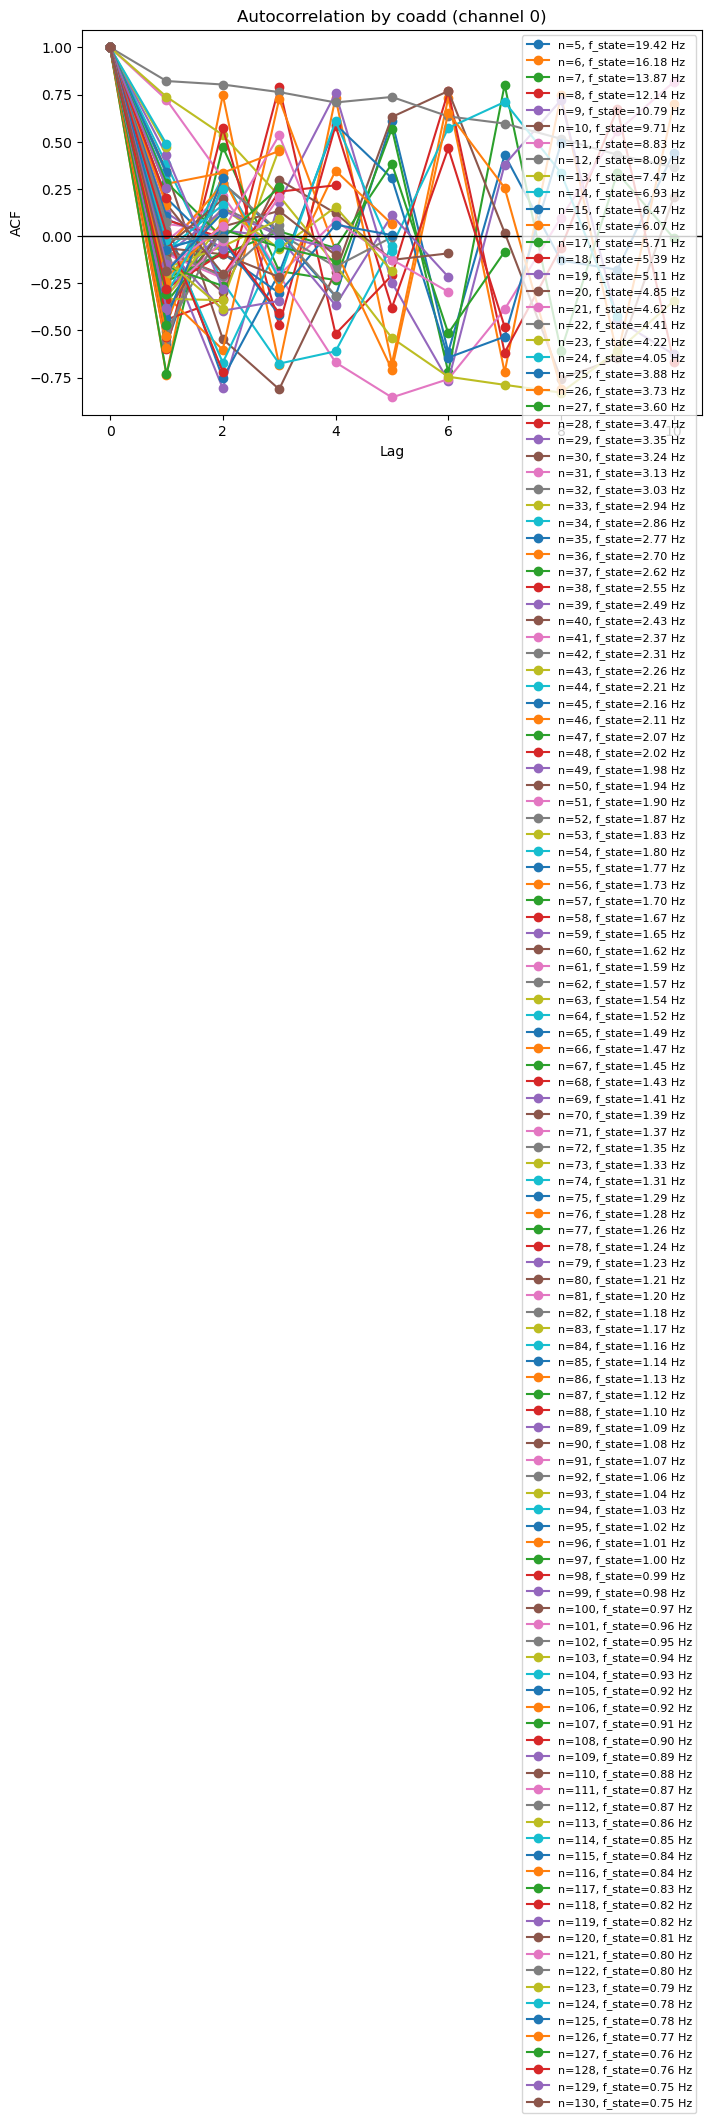

/tmp/ipykernel_1522175/524184095.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


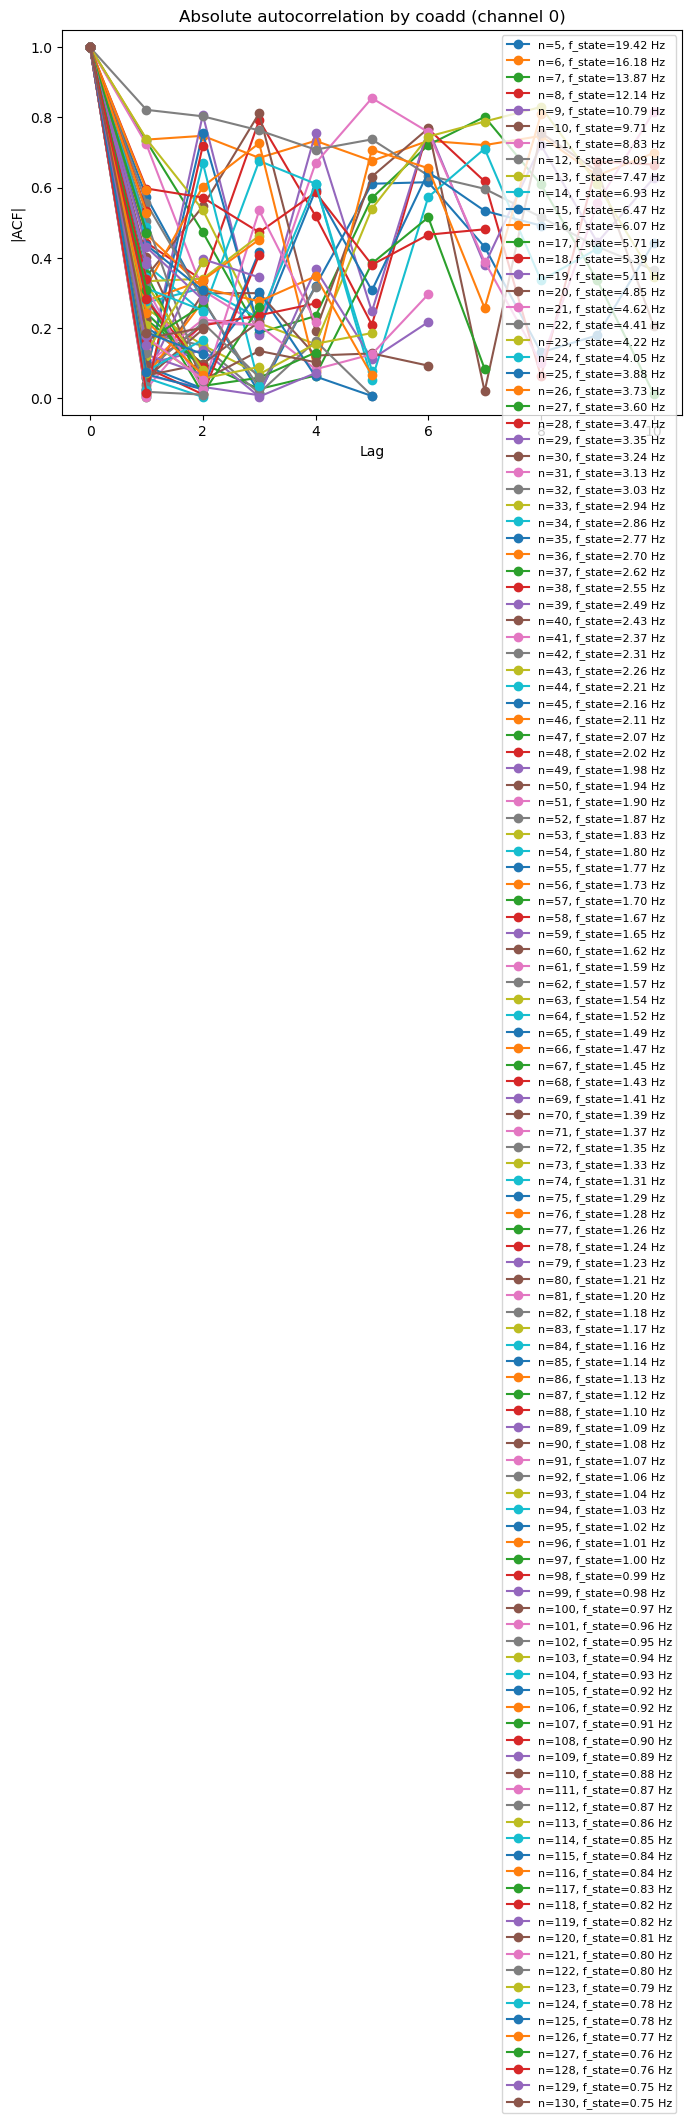

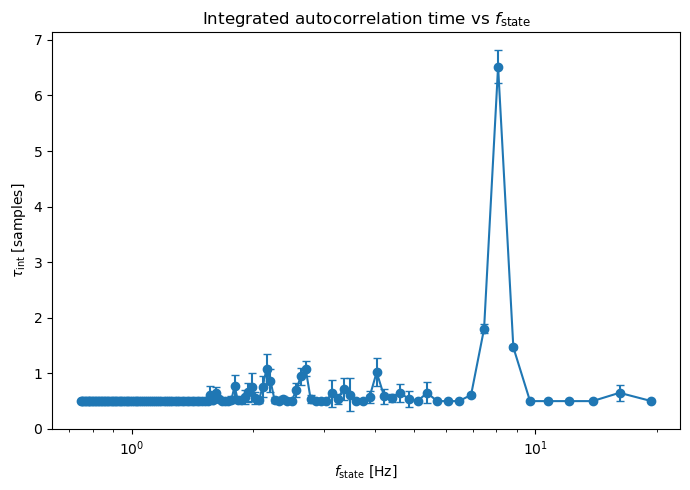

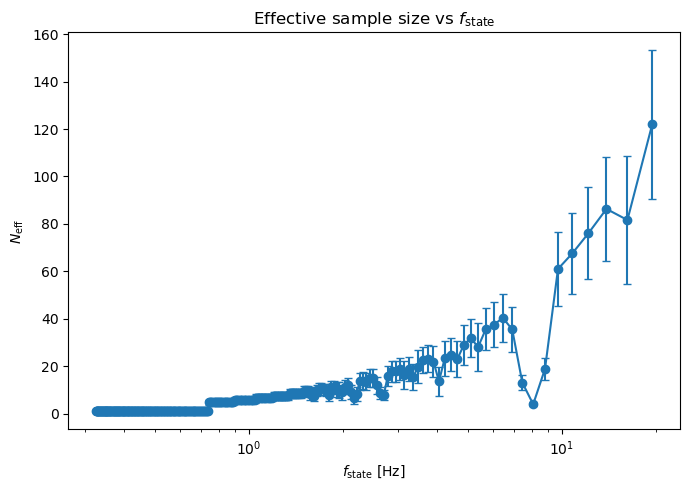

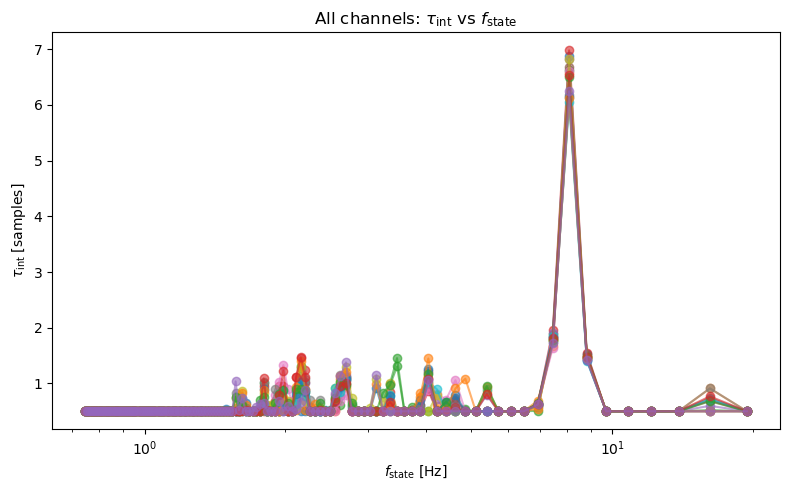

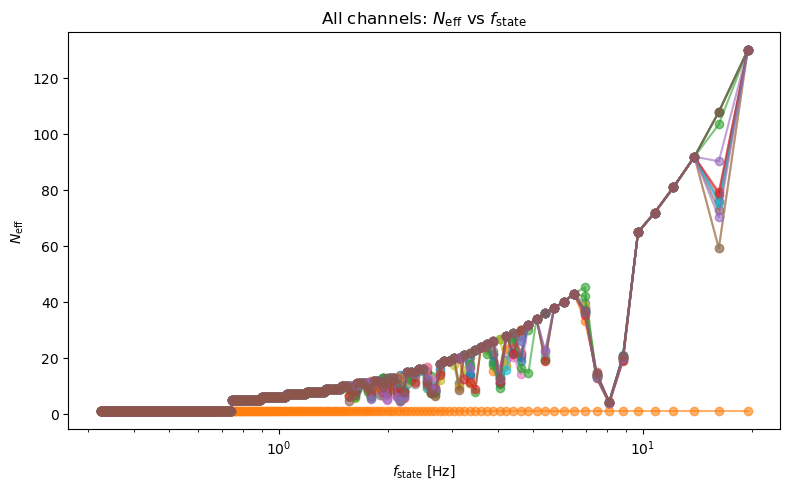

In [41]:
plot_acf_by_coadd(acf_by_coadd, meta["f_state"], channel=0)
plot_abs_acf_by_coadd(acf_by_coadd, meta["f_state"], channel=0)

plot_tau_by_coadd_vs_fstate(tau_by_coadd, meta["f_state"])
plot_neff_by_coadd_vs_fstate(neff_by_coadd, meta["f_state"])

plot_tau_all_channels_vs_fstate(tau_by_coadd, meta["f_state"])
plot_neff_all_channels_vs_fstate(neff_by_coadd, meta["f_state"])

In [42]:
neff_by_coadd

{5: array([130., 130., 130., 130., 130., 130., 130., 130., 130., 130., 130.,
          1., 130., 130., 130., 130.]),
 6: array([ 76.3315538 ,  59.40107115, 103.5551946 ,  78.35890237,
         90.34021171,  72.96286174, 108.        ,  59.1951619 ,
        108.        ,  75.32896124, 108.        ,   1.        ,
        108.        ,  79.37096119,  70.35594988, 108.        ]),
 7: array([92., 92., 92., 92., 92., 92., 92., 92., 92., 92., 92.,  1., 92.,
        92., 92., 92.]),
 8: array([81., 81., 81., 81., 81., 81., 81., 81., 81., 81., 81.,  1., 81.,
        81., 81., 81.]),
 9: array([72., 72., 72., 72., 72., 72., 72., 72., 72., 72., 72.,  1., 72.,
        72., 72., 72.]),
 10: array([65., 65., 65., 65., 65., 65., 65., 65., 65., 65., 65.,  1., 65.,
        65., 65., 65.]),
 11: array([19.29005859, 19.83768007, 20.04294985, 19.04603121, 20.02106017,
        19.51241643, 20.62194377, 20.45581429, 20.29393055, 20.97634875,
        20.64204093,  1.        , 20.23381729, 19.9332551 , 19.9557

In [43]:
def compute_inv_neff_mean(n_eff_by_coadd):
    """
    Compute <1 / N_eff> for each coadd.

    Parameters
    ----------
    n_eff_by_coadd : dict
        Keys = coadd values
        Values = arrays of shape (n_channels,)

    Returns
    -------
    inv_neff_mean_by_coadd : dict
        <1 / N_eff> per coadd

    neff_effective_by_coadd : dict
        Effective N_eff = 1 / <1 / N_eff>
    """
    inv_neff_mean_by_coadd = {}
    neff_effective_by_coadd = {}

    for n, neff in n_eff_by_coadd.items():
        neff = np.asarray(neff, dtype=float)

        # Mask bad values
        mask = np.isfinite(neff) & (neff > 0)

        if np.sum(mask) == 0:
            inv_mean = np.nan
            neff_eff = np.nan
        else:
            inv_mean = np.mean(1.0 / neff[mask])
            neff_eff = 1.0 / inv_mean

        inv_neff_mean_by_coadd[n] = inv_mean
        neff_effective_by_coadd[n] = neff_eff

    return inv_neff_mean_by_coadd, neff_effective_by_coadd

In [44]:
inv_neff_mean_by_coadd, neff_eff_by_coadd = compute_inv_neff_mean(neff_by_coadd)

In [45]:
# Plot the inv neff values for each channel as a function of coadd, and also plot the effective neff as a function of coadd.
# turn this into an array 
inv_neff_mean_by_coadd_array = np.array([inv_neff_mean_by_coadd[n] for n in sorted(inv_neff_mean_by_coadd.keys())], dtype=float)

## Compute $\sigma^2_{corr}(f_c)$

Text(0, 0.5, 'Expected Variance of Correlated Reference')

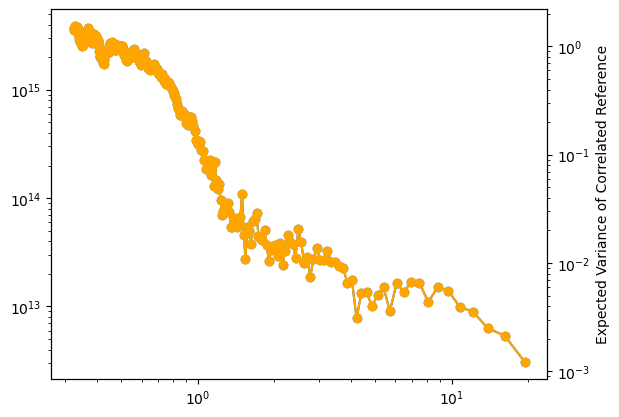

In [34]:
# Use channel 13 as an example 
expected_var_corr_ref = var_corr_ref[12] * R_factor[12, :]
plt.plot(f_state, expected_var_corr_ref, marker='o', label=f'Channel 13')
plt.yscale('log')
# Use other y axiis to plot the actual R values on the same plot
plt.twinx()
plt.plot(f_state, R_factor[12, :], marker='o', color='orange', label='R values')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Expected Variance of Correlated Reference')

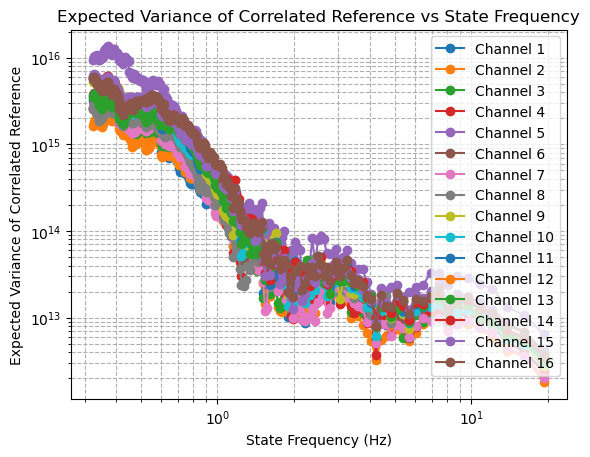

In [35]:
# Mulitply the the correlated reference variance by the R(f_c) values to get the expected variance of the correlated reference at each state frequency for each channel

# Initialize array to store the expected variance of the correlated reference for each channel and state frequency
expected_var_corr_ref_all = np.zeros_like(R_factor)

for channel in range(result["channels"].shape[0]):
    expected_var_corr_ref = var_corr_ref[channel] * R_factor[channel, :]
    expected_var_corr_ref_all[channel, :] = expected_var_corr_ref
    plt.plot(f_state, expected_var_corr_ref, marker='o', label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Expected Variance of Correlated Reference')
plt.title('Expected Variance of Correlated Reference vs State Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")

## this part is buggy (relies on calculation of the effective smaples)

In [36]:
# Multiply by the inv neff mean to get the expected variance of the correlated reference divided by the effective N_eff for each channel and state frequency
expected_var_corr_ref_all_div_neff = expected_var_corr_ref_all[12] * inv_neff_mean_by_coadd_array

NameError: name 'inv_neff_mean_by_coadd_array' is not defined

In [ ]:
# Plot the 
plt.figure(figsize=(10, 6))
plt.plot(f_state, expected_var_corr_ref_all_div_neff, marker='o', label=f'Channel 13 with N_eff correction')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Expected Variance of Correlated Reference / N_eff')
plt.title('Expected Variance of Correlated Reference with N_eff correction vs State Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")

NameError: name 'expected_var_corr_ref_all_div_neff' is not defined

<Figure size 1000x600 with 0 Axes>

Using values from Harris 1998 (the NEATM Model paper), we can establish a fidical value for the asteroid. The nice thing about using literature values is that they are geomery, and object constrained. That is to say, thiis the known flux for that object at the specific distance it was observed. 

## Signal for asteroid

From looking at the plots, it seems like the flux throughout N-band (8.5 - 13 microns is something like 9 x 10^-13 W /m^2/micron). We adopt this as the a uniform "in-band value"

[ 77475.     77764.472  78053.945  78343.417  78632.889  78922.362
  79211.834  79501.307  79790.779  80080.251  80369.724  80659.196
  80948.668  81238.141  81527.613  81817.085  82106.558  82396.03
  82685.503  82974.975  83264.447  83553.92   83843.392  84132.864
  84422.337  84711.809  85001.281  85290.754  85580.226  85869.698
  86159.171  86448.643  86738.116  87027.588  87317.06   87606.533
  87896.005  88185.477  88474.95   88764.422  89053.894  89343.367
  89632.839  89922.312  90211.784  90501.256  90790.729  91080.201
  91369.673  91659.146  91948.618  92238.09   92527.563  92817.035
  93106.508  93395.98   93685.452  93974.925  94264.397  94553.869
  94843.342  95132.814  95422.286  95711.759  96001.231  96290.704
  96580.176  96869.648  97159.121  97448.593  97738.065  98027.538
  98317.01   98606.482  98895.955  99185.427  99474.899  99764.372
 100053.84  100343.32  100632.79  100922.26  101211.73  101501.21
 101790.68  102080.15  102369.62  102659.1   102948.57  103238.0

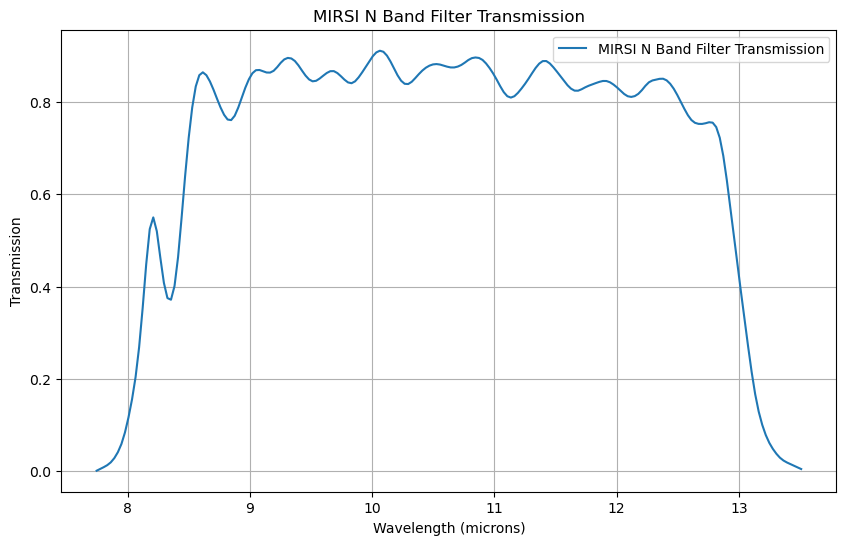

In [37]:

# First read in the filter transmission curve from the file
# load the filter profile from the .dat file 
filter_wl, filter_trans = np.genfromtxt('IRTF_MIRSI.N.dat', unpack=True)
#%%
print(filter_wl)
#%% 
# Convert filter wl from angstroms to nm 
filter_wl_microns = filter_wl / 10000.0  # angstroms to microns

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(filter_wl_microns, filter_trans, label='MIRSI N Band Filter Transmission')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Transmission')
plt.title('MIRSI N Band Filter Transmission')
plt.legend()
plt.grid(True)
plt.show()

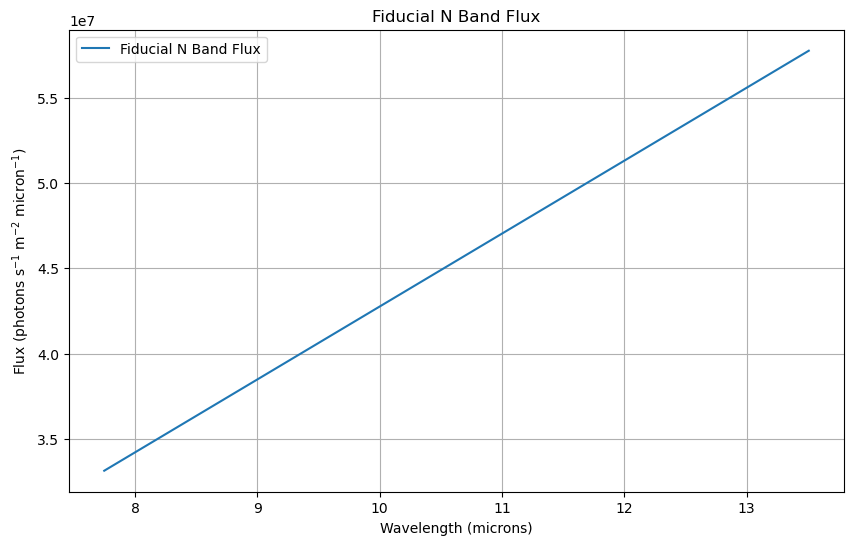

In [38]:
# Make a fudicial plot which is a tophat function with the value of 8.5e-13 W m^-2 micron^-1 over the N Band (same wavelength range as the filter) and zero elsewhere. Convert this to photons/s/m^2/micron and plot it on the same plot as the filter transmission curve. This is just a rough estimate of the expected flux in the N band for a bright source, but it will allow us to visualize how the expected flux compares to the filter transmission.
n_band_flux = np.full_like(filter_wl_microns, 8.5e-13)  # W m^-2 micron^-1
# Convert to photons/s/m^2/micron using the energy of the photons at that wavelength (E = hc/lambda)
h = 6.626e-34  # Planck's constant in J*s
c = 3e8  # Speed of light in m/s
n_band_flux_photons = n_band_flux * (filter_wl_microns * 1e-6) / (h * c)  # photons/s/m^2/micron
plt.figure(figsize=(10, 6))
plt.plot(filter_wl_microns, n_band_flux_photons, label='Fiducial N Band Flux')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (photons s$^{-1}$ m$^{-2}$ micron$^{-1}$)')
plt.title('Fiducial N Band Flux')
plt.legend()
plt.grid(True)
plt.show()

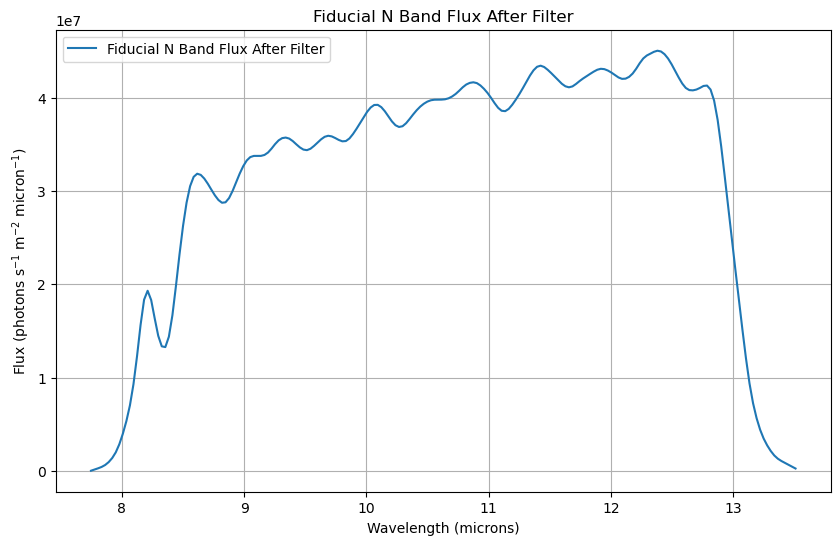

In [39]:
# Now multiply the fiducial N band flux by the filter transmission to get the expected flux after the filter - they're the same shape so just multiply elementwise
n_band_flux_after_filter = n_band_flux_photons * filter_trans

plt.figure(figsize=(10, 6))
plt.plot(filter_wl_microns, n_band_flux_after_filter, label='Fiducial N Band Flux After Filter')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (photons s$^{-1}$ m$^{-2}$ micron$^{-1}$)')
plt.title('Fiducial N Band Flux After Filter')
plt.legend()
plt.grid(True)
plt.show()

The shape makes sense - for the same flux, you expect less photons (more energetic). Convert this to a photon rate by integrating over the wavelength range of the filter and multiplying by the collecting area of the telescope and the solid angle of a pixel to get the expected photon rate in a pixel from this fiducial source after the filter. This will allow us to compare it to the sky background photon rate we calculated earlier.


In [40]:
# Convert this to a photon rate by integrating over the wavelength range of the filter and multiplying by the collecting area of the telescope and the solid angle of a pixel to get the expected photon rate in a pixel from this fiducial source after the filter. This will allow us to compare it to the sky background photon rate we calculated earlier.
# First integrate the flux after the filter over the wavelength range of the filter to get the total flux in photons/s/m^2
from scipy.integrate import simpson
integrated_flux_asteroid = simpson(n_band_flux_after_filter, filter_wl_microns)  # photons/s/m^2

In [41]:
print(f"Integrated flux of the fiducial source after the filter: {integrated_flux_asteroid:.3e} ph/s/m^2")

Integrated flux of the fiducial source after the filter: 1.830e+08 ph/s/m^2


In this case, the aperture is 6 arcseconds. (what I assume is a diameter). this corresponds to an area of SA = pi*(3**2) arcseconds. The number of pixels in that is then SA/omega_pix.

In [42]:
SA = np.pi * (3**2) # solid angle in arcsec^2 of a 3 arcsec radius aperture

n_pixels = SA / omega_pix  # number of pixels in the aperture

print(f"Number of pixels in a 3 arcsec radius aperture: {n_pixels:.2f}")
print(f"which is about {np.sqrt(n_pixels):.2f} x {np.sqrt(n_pixels):.2f} pixels")

Number of pixels in a 3 arcsec radius aperture: 387.85
which is about 19.69 x 19.69 pixels


In [43]:
# We know that the collecting area of the telescope is A_tel and the solid angle of a pixel is omega_pix, so we can multiply the integrated flux by these to get the expected photon rate in a pixel from this fiducial source on the detector
expected_photon_rate_asteroid = integrated_flux_asteroid * A_tel * eta_tel * QE / n_pixels
print(f"Expected photon rate in a pixel from the fiducial source on detector: {expected_photon_rate_asteroid:.3e} ph/s/pixel)")

Expected photon rate in a pixel from the fiducial source on detector: 7.033e+05 ph/s/pixel)


Is this reasonable? We should check by comparing this with the sky and the telescope rates and we expect to be background limited. 

Sky photons per second per pixel: 2.504e+08 ph/s/pix


## Compute the sky shot noise

Given the sky rate, the shot noise is just $\sqrt{N}$

This seems unrealistically high, how much does read noise play a part in these measurements? 

In [44]:
def signal_to_noise(source_rate, sky_rate, t_int, channel, f_state):
    # correlated variance per differenced sample
    var_corr_per_sample = expected_var_corr_ref_all[channel, :]

    # if each sample is approximately independent
    N_samples = t_int * np.asarray(f_state)

    # variance of the mean over the total integration
    var_corr_total = var_corr_per_sample / N_samples

    # Poisson variance over total integration
    var_poisson = (source_rate + sky_rate) * t_int

    snr = (source_rate * t_int) / (np.sqrt(2) * np.sqrt(var_poisson + var_corr_total))
    return snr

In [45]:
print(f_state)

[19.41747572815534, 16.181229773462782, 13.869625520110958, 12.135922330097086, 10.787486515641856, 9.70873786407767, 8.8261253309797, 8.090614886731391, 7.468259895444362, 6.934812760055479, 6.472491909385114, 6.067961165048543, 5.711022272986864, 5.393743257820928, 5.109862033725089, 4.854368932038835, 4.623208506703652, 4.41306266548985, 4.221190375685944, 4.0453074433656955, 3.883495145631068, 3.734129947722181, 3.595828838547285, 3.4674063800277395, 3.3478406427854033, 3.236245954692557, 3.1318509238960224, 3.0339805825242716, 2.9420417769932334, 2.855511136493432, 2.7739251040221915, 2.696871628910464, 2.623983206507478, 2.5549310168625445, 2.4894199651481204, 2.4271844660194173, 2.3679848448969927, 2.311604253351826, 2.2578460149017836, 2.206531332744925, 2.157497303128371, 2.110595187842972, 2.0656889072505678, 2.0226537216828477, 1.9813750743015652, 1.941747572815534, 1.9036740909956216, 1.8670649738610905, 1.8318373328448432, 1.7979144192736425, 1.7652250661959399, 1.73370319

In [46]:
t_int = 0.0103
test_SNR = signal_to_noise(expected_photon_rate_asteroid, sky_photons_per_pixel_per_second, t_int, channel=13, f_state=f_state[::-1])

Text(0, 0.5, 'Signal-to-Noise Ratio (SNR)')

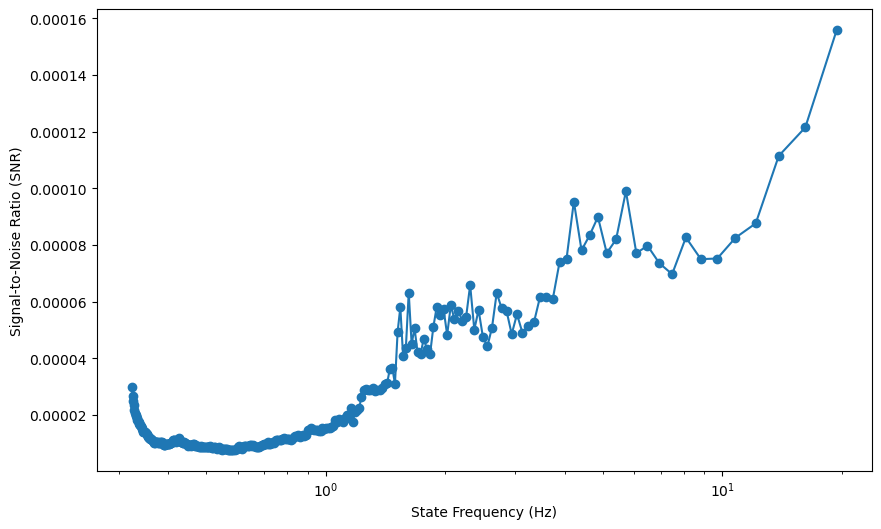

In [47]:
#Plot 
plt.figure(figsize=(10, 6))
plt.plot(f_state, test_SNR, marker='o', label='SNR for Fiducial Source')
plt.xscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Signal-to-Noise Ratio (SNR)')   

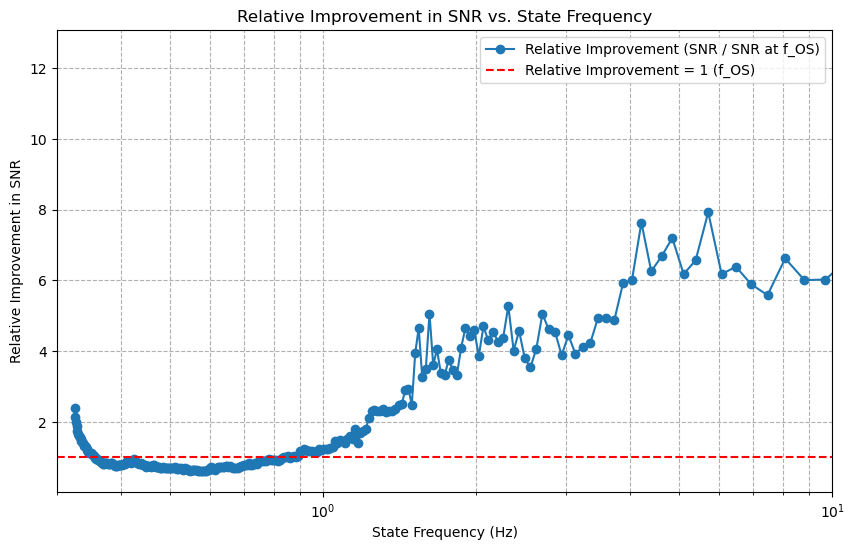

In [48]:
# compute the SNR at f_OS and plot the relative improvement as before
SNR_at_f_OS = np.interp(f_OS, f_state[::-1], test_SNR)
relative_improvement = test_SNR / SNR_at_f_OS

plt.figure(figsize=(10, 6))
plt.plot(f_state, relative_improvement, marker='o', label='Relative Improvement (SNR / SNR at f_OS)')
plt.axhline(1, color='red', linestyle='--', label='Relative Improvement = 1 (f_OS)')
plt.xscale('log')   
plt.xlabel('State Frequency (Hz)')
plt.xlim(3e-1,1e1)
plt.ylabel('Relative Improvement in SNR')
plt.title('Relative Improvement in SNR vs. State Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")   

# Improvement in SNR

In [49]:
# Find the relative improvement at the max value of the plot less than 10 Hz
# Ensure both are numpy arrays
f_state_arr = np.asarray(f_state)
relative_improvement_arr = np.asarray(relative_improvement)

# Find max where f_state < 10
mask = f_state_arr < 10
max_relative_improvement = np.max(relative_improvement_arr[mask])
print(f"Maximum relative improvement (f < 10 Hz): {max_relative_improvement:.2f}")

# Optionally, also find the frequency at which this occurs
f_at_max = f_state_arr[mask][np.argmax(relative_improvement_arr[mask])]
print(f"Occurs at frequency: {f_at_max:.2f} Hz")

Maximum relative improvement (f < 10 Hz): 7.92
Occurs at frequency: 5.71 Hz


For a fixed SNR threshold (e.g.) detection limit, the SNR scales linearly with flux.

In [50]:
delta_m = 2.5 * np.log10(max_relative_improvement)
print(f"Equivalent improvement in magnitude: {delta_m:.2f} mag")

Equivalent improvement in magnitude: 2.25 mag


## Test on NEATM

First move to the directory with NEATM 

In [69]:
import sys 
sys.path.append(os.path.expanduser("~/github/NEATM/neatm"))

In [70]:
import neatm

In [71]:
import neatm
import astropy.units as u

flux = neatm.neatm(
    h=17.0,
    g=0.15,
    alpha=30*u.deg,
    r=1.2*u.au,
    delta=0.4*u.au,
    wavelengths=10*u.um,
    eta=1.0,
    pv=0.15
)

print(flux)

162.143 mJy


In [72]:
import astropy.units as u

old_limit = 4.0 * u.mJy
t_int = 60.0 * u.s

In [73]:
import astropy.units as u

old_limit = 4.0 * u.mJy
improvement = 4.26
new_limit = old_limit / improvement

print(f"Old 60 s sensitivity: {old_limit:.3f}")
print(f"New 60 s sensitivity: {new_limit:.3f}")

Old 60 s sensitivity: 4.000 mJy
New 60 s sensitivity: 0.939 mJy


In [74]:
import astropy.units as u

g = 0.15
alpha = 48.3 * u.deg
r = 1.131 * u.au
delta = 0.246 * u.au
eta = 1.0
pv = 0.2

In [75]:
import numpy as np
import astropy.units as u

def neatm_nband_flux(h, g, alpha, r, delta, eta, pv,
                     lam_min=8.5*u.um, lam_max=13.0*u.um, nlam=100):
    wavelengths = np.linspace(lam_min.value, lam_max.value, nlam) * u.um
    f = neatm.neatm(h, g, alpha, r, delta, wavelengths, eta, pv, mJy=True)
    f = u.Quantity(f)
    return np.mean(f)

In [76]:
f_test = neatm_nband_flux(
    h=14.51,
    g=g,
    alpha=alpha,
    r=r,
    delta=delta,
    eta=eta,
    pv=pv
)

print("Model N-band flux:", f_test)
print("Detected with old limit?", f_test >= old_limit)
print("Detected with new limit?", f_test >= new_limit)

Model N-band flux: 3064.5697000000005 mJy
Detected with old limit? True
Detected with new limit? True


In [77]:
def find_limiting_H(flux_limit, g, alpha, r, delta, eta, pv,
                    h_grid=np.linspace(15, 30, 500)):
    fluxes = []
    for h in h_grid:
        f = neatm_nband_flux(h, g, alpha, r, delta, eta, pv)
        fluxes.append(f.to_value(u.mJy))

    fluxes = np.array(fluxes)
    limit_val = flux_limit.to_value(u.mJy)

    valid = np.where(fluxes >= limit_val)[0]
    if len(valid) == 0:
        return None

    return h_grid[valid[-1]]

In [78]:
h_lim_old = find_limiting_H(old_limit, g, alpha, r, delta, eta, pv)
h_lim_new = find_limiting_H(new_limit, g, alpha, r, delta, eta, pv)

print("Old limiting H:", h_lim_old)
print("New limiting H:", h_lim_new)

Old limiting H: 21.703406813627254
New limiting H: 23.266533066132265


In [79]:
h_lim_new - h_lim_old

1.5631262525050111

In [80]:
def H_to_diameter_km(H, pv):
    return 1329.0 * 10**(-H/5.0) / np.sqrt(pv)

d_old = H_to_diameter_km(h_lim_old, pv)
d_new = H_to_diameter_km(h_lim_new, pv)

print("Old limiting diameter [km]:", d_old)
print("New limiting diameter [km]:", d_new)

Old limiting diameter [km]: 0.1356215240258406
New limiting diameter [km]: 0.0660242337832247


## Grid of allowed geometries

In [ ]:
channel = 12
var_poisson = (source_rate + sky_rate) * t_int
var_corr_per_sample = expected_var_corr_ref_all[channel, :]
N_samples = t_int * f_state
var_corr_total = var_corr_per_sample / N_samples

print("Poisson variance:", var_poisson)
print("Correlated variance per sample min/max:", var_corr_per_sample.min(), var_corr_per_sample.max())
print("Correlated variance after averaging min/max:", var_corr_total.min(), var_corr_total.max())
print("Ratio total_corr / poisson min/max:", (var_corr_total / var_poisson).min(), (var_corr_total / var_poisson).max())

NameError: name 'source_rate' is not defined

def signal_to_noise(source_rate, sky_rate, t_int, channel, f_state):
    # correlated variance per differenced sample
    var_corr_per_sample = expected_var_corr_ref_all[channel, :]

    # if each sample is approximately independent
    N_samples = t_int * f_state

    # variance of the mean over the total integration
    var_corr_total = var_corr_per_sample / N_samples

    # Poisson variance over total integration

    snr = (source_rate * t_int) / (np.sqrt(2) * np.sqrt(var_poisson + var_corr_total))
    return snr

In [ ]:
print(f_state[::-1][2])

In [ ]:
print(sky_photons_per_pixel_per_second)

In [ ]:
# Find the expected variacne from just the sky (poisson noise) 
vars_poisson = np.zeros(np.shape(f_state))
for i in range(len(f_state)):
    vars_poisson[i] = sky_photons_per_pixel_per_second / f_state[::-1][i]
plt.figure(figsize=(10, 6))
plt.plot(f_state, vars_poisson, marker='o', label='Poisson Variance from Sky')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Variance (photons$^2$ s$^{-1}$ pixel$^{-1}$)')
plt.title('Poisson Variance from Sky vs State Frequency')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

From the 

In [ ]:
F_ast = 

clearly channel 12 has something wrong with it. maybe what we can do is take the median of each and normalize the values to the "empirical sky rate".   

In [ ]:
num_channels = 16
channel_width = 20

zenith_sky_1_data_norm = zenith_sky_1_data.astype(float).copy()

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_norm[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

In [ ]:
# normalize each channel by the median of itself 
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    med = np.nanmedian(channel)
    if med != 0:
        zenith_sky_1_data_norm[:, :, c0:c1] = channel / med

    im = axes[i//(num_channels//2), i%(num_channels//2)].imshow(zenith_sky_1_data_norm[0, :, c0:c1], cmap='gray', origin='lower')
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} (normalized)")
    plt.colorbar(im, ax=axes[i//(num_channels//2), i%(num_channels//2)], pad=0.01)


In [ ]:
# histograms for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Pixel Value")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)")

plt.tight_layout()
plt.show()

Now, multiply the pixel value by the expected number of sky photons

In [ ]:
# Multiply each pixel value by the sky photon rate per pixel
sky_rate = 9087.657082019272 # ph/pix

# muliply zenith_sky_1_data_norm by the sky rate to get an estimate of the photon counts per pixel if not nan
zenith_sky_1_data_photons = np.where(np.isnan(zenith_sky_1_data_norm), np.nan, zenith_sky_1_data_norm * sky_rate)

# Generate histograms of the photon counts for each channel
fig, axes = plt.subplots(2, num_channels//2, figsize=(32, 8))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Photon Counts per Pixel")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)") 

    # axvline for the median photon count in this channel
    median_photon_count = np.median(channel)
    axes[i//(num_channels//2), i%(num_channels//2)].axvline(median_photon_count, color='red', linestyle='dashed', label=f'Median: {median_photon_count:.1f} ph/pix')
    axes[i//(num_channels//2), i%(num_channels//2)].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Now that we have a gain measurment, we don't need to do the nomralization by the median for each channel, we can just convert the original data to photon counts directly and then analyze the timeseries. Let's do that and then compute the variance of the timeseries for each channel to see how it compares to our gain measurement.
Gain = 350 # e-/photon
#make a copy of the original data and convert to photon counts using the gain
zenith_sky_1_data_photons = zenith_sky_1_data.astype(float).copy() / Gain

#Plot the channels 
fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_photons[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

In [ ]:
#Plot the histograms of the photon counts for each channel (in a a 4x4 grid)
fig, axes = plt.subplots(4, num_channels//4, figsize=(16,16))
for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]
    
    # Ignoring NaNs for histogram
    channel = channel[~np.isnan(channel)]
    axes[i//(num_channels//2), i%(num_channels//2)].hist(channel.flatten(), bins=50, log=True)
    axes[i//(num_channels//2), i%(num_channels//2)].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i//(num_channels//2), i%(num_channels//2)].set_xlabel("Photon Counts per Pixel")
    axes[i//(num_channels//2), i%(num_channels//2)].set_ylabel("Count (log scale)") 

    # axvline for the median photon count in this channel
    median_photon_count = np.median(channel)
    axes[i//(num_channels//2), i%(num_channels//2)].axvline(median_photon_count, color='red', linestyle='dashed', label=f'Median: {median_photon_count:.1f} ph/pix')
    axes[i//(num_channels//2), i%(num_channels//2)].legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    channel = zenith_sky_1_data_photons[:, :, c0:c1]

    channel = channel[~np.isnan(channel)]

    axes[i].hist(channel.flatten(), bins=50, log=True)
    axes[i].set_title(f"Channel {i+1} Photon Counts Histogram")
    axes[i].set_xlabel("Photon Counts per Pixel")
    axes[i].set_ylabel("Count (log scale)")

    median_photon_count = np.median(channel)
    axes[i].axvline(
        median_photon_count,
        color='red',
        linestyle='dashed',
        label=f"Median: {median_photon_count:.1f} ph/pix"
    )
    axes[i].legend()

plt.tight_layout()
plt.show()

## Channel 2 Injection

In [ ]:
channel = 2
c0 = channel * channel_width
c1 = (channel + 1) * channel_width
ch2 = zenith_sky_1_data_photons[:, :, c0:c1]
plt.imshow(ch2[0], cmap='gray', origin='lower')
plt.title(f"Channel {channel+1} Photon Counts (first frame)")
plt.colorbar(label="Photon Counts per Pixel")
plt.show()

In [ ]:
# For IRTF, the pixel scale is 0.27" and the diffraction limited psf has a FWHM of 0.84" 
# Determine the FWHM in pixels
pixel_scale = 0.27 # arcsec/pixel
FWHM_arcsec = 0.84 # arcsec
FWHM_pixels = FWHM_arcsec / pixel_scale
print(f"FWHM in pixels: {FWHM_pixels:.2f} pixels")

In [ ]:
# inject a fake point source into ch2 
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amplitude):
    return amplitude * np.exp(-(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2)))

def sigma(FWHM_pixels):
    # assume a FWHM of 3 pixels for the point source
    sigma = FWHM_pixels / (2 * np.sqrt(2 * np.log(2)))
    return sigma

In [ ]:
def inject_point_source(image, x0, y0, FWHM_pixels, amplitude):
    sigma_x = sigma(FWHM_pixels)
    sigma_y = sigma(FWHM_pixels)
    
    # Create a grid of x and y coordinates
    y, x = np.indices(image.shape)
    
    # Generate the 2D Gaussian PSF
    psf = gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amplitude)

    # Add shot noise to the PSF (assuming Poisson statistics)
    psf_noisy = np.random.poisson(psf)
    
    # Inject the point source into the image
    injected_image = image + psf_noisy
    
    return injected_image

In [ ]:
# Inject point source at (10, 100)
x0, y0 = 10, 100

# Amplitudes 
frac_amplitudes = [0.001, 0.1, 0.5, 1., 50, 100]
# For each amplitude, inject the point source and plot the result
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, amp in enumerate(frac_amplitudes):
    injected_image = inject_point_source(ch2[0], x0, y0, FWHM_pixels, amp * sky_rate)

    # perform aperture photometry on the injected image to see if we can recover the injected flux
# perform aperture photometry on the injected image to see if we can recover the injected flux
    positions = [(x0, y0)]
    aperture = CircularAperture(positions, r=FWHM_pixels)
    annulus_aperture = CircularAnnulus(positions, r_in=FWHM_pixels*1.5, r_out=FWHM_pixels*2.5)
    aperture_masks = aperture.to_mask(method='center')
    annulus_masks = annulus_aperture.to_mask(method='center')
    aperture_data = aperture_masks[0].multiply(injected_image)
    annulus_data = annulus_masks[0].multiply(injected_image)
    aperture_sum = np.nansum(aperture_data)
    annulus_sum = np.nansum(annulus_data)
    annulus_area = annulus_aperture.area  # This is already just the annulus area
    background_per_pixel = annulus_sum / annulus_area
    signal = aperture_sum - (background_per_pixel * aperture.area)
    noise = np.sqrt(aperture_sum + (background_per_pixel * aperture.area))
    snr = signal / noise if noise > 0 else 0

    # Draw the annulus and aperture on the image
    aperture.plot(ax, color='red', lw=0.5)
    annulus_aperture.plot(ax, color='blue', lw=0.5)


    ax = axes[i//3, i%3]
    im = ax.imshow(injected_image, cmap='gray', origin='lower')
    ax.set_title(f"Injected Point Source (Amplitude: {amp} * sky_rate )\nSNR: {snr:.2f}")
    plt.colorbar(im, ax=ax, pad=0.01)

In [ ]:
# Draw apertures for photometry and compute the signal-to-noise ratio for each injected source
